# Tent Analysis in LA

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import shap
import argparse, json, os, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

In [ ]:
#######

In [ ]:
## 0.25

In [2]:
import pandas as pd
df_25 = pd.read_csv('/content/quarter_variables_and_tents_geo_enriched.csv')

In [3]:
print(df_25['GRID_ID'].nunique())

1448


In [4]:
df_25

,OBJECTID,Join_Count,TARGET_FID,JOIN_FID,GRID_ID,ID,sourceCountry,ENRICH_FID,aggregationMethod,populationToPolygonSizeRating,...,la_geohub_fire_hazard_intersects,heat_exposure_area_pct,heat_exposure_intersects,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,dominant_landcover_class,heat_exposure_proxy_score
0,1,0,1,-1,AP-81,0,US,1,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,...,1,0.0,0,1.80,46.13,22.68,1.29,29.90,3,45.34
1,2,1,2,1522,AQ-81,1,US,2,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,...,1,0.0,0,1.25,33.86,35.74,1.88,28.53,5,54.64
2,3,1,2,1524,AQ-81,1,US,2,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,...,1,0.0,0,1.25,33.86,35.74,1.88,28.53,5,54.64
3,4,0,3,-1,AR-81,2,US,3,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,...,1,0.0,0,0.23,7.71,14.72,55.37,22.20,6,40.24
4,5,0,4,-1,AP-80,3,US,4,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,...,1,0.0,0,1.95,28.77,45.29,1.07,24.87,5,61.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2873,2874,1,1444,1648,X-2,43,US,1444,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,...,1,0.0,0,2.48,37.35,32.39,1.59,28.67,5,51.93
2874,2875,0,1445,-1,Y-2,44,US,1445,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,...,1,0.0,0,5.82,33.51,40.56,1.94,23.99,5,56.65
2875,2876,0,1446,-1,U-1,45,US,1446,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,...,1,0.0,0,4.98,43.47,24.05,1.72,30.76,4,45.34
2876,2877,0,1447,-1,W-1,46,US,1447,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,...,1,0.0,0,17.70,67.53,9.45,1.37,21.65,3,31.30


In [5]:
import pandas as pd
df_tent = pd.read_csv('/content/outputLayer_0 7.csv')

In [6]:
df_25 = pd.merge(df_tent,df_25,on = 'OBJECTID',how='inner' )

In [7]:
df_25.shape

(1448, 134)

In [8]:
df_25

,OBJECTID,Join_Count_x,TARGET_FID_x,GRID_ID_x,Id,Country code,ENRICH_FID_x,Aggregation method,Population to polygon size rating for the country,Apportionment confidence for the country,...,la_geohub_fire_hazard_intersects,heat_exposure_area_pct,heat_exposure_intersects,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,dominant_landcover_class,heat_exposure_proxy_score
0,1,0,1,AP-81,0,US,1,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,2.576,...,1,0.0,0,1.80,46.13,22.68,1.29,29.90,3,45.34
1,2,0,2,AQ-81,1,US,2,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,2.576,...,1,0.0,0,1.25,33.86,35.74,1.88,28.53,5,54.64
2,3,0,3,AR-81,2,US,3,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,2.576,...,1,0.0,0,1.25,33.86,35.74,1.88,28.53,5,54.64
3,4,0,4,AP-80,3,US,4,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,2.576,...,1,0.0,0,0.23,7.71,14.72,55.37,22.20,6,40.24
4,5,0,5,AQ-80,4,US,5,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,2.576,...,1,0.0,0,1.95,28.77,45.29,1.07,24.87,5,61.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,1444,0,1444,X-2,43,US,1444,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,2.576,...,1,0.0,0,1.24,18.37,60.95,1.94,18.73,5,72.29
1444,1445,0,1445,Y-2,44,US,1445,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,2.576,...,1,0.0,0,5.00,34.48,35.52,1.72,28.28,5,53.36
1445,1446,0,1446,U-1,45,US,1446,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,2.576,...,1,0.0,0,9.57,35.82,42.20,2.30,19.68,5,56.67
1446,1447,0,1447,W-1,46,US,1447,BlockApportionment:US.BlockGroups;PointsLayer:...,2.191,2.576,...,1,0.0,0,0.52,24.14,46.72,1.03,28.10,5,62.55


In [9]:
df_25['Join_Count_x'].value_counts()

,count
Join_Count_x,
0,1083
1,174
2,61
3,39
4,25
5,15
6,14
9,7
7,5


In [10]:
df_25.shape

(1448, 134)

In [11]:
df_25 =  df_25.rename(columns = {'Join_Count_x':'Join_Count'})

In [12]:
# Identify all columns to be dropped for feature processing, including ID/coordinate columns
columns_to_drop_for_features = [
    'OBJECTID','TARGET_FID_x','JOIN_FID','ID','sourceCountry','ENRICH_FID_x','aggregationMethod','populationToPolygonSizeRating','apportionmentConfidence','HasData',
    'ID_1','sourceCountry_1','ENRICH_FID_1','populationToPolygonSizeRating_1','aggregationMethod_1','populationToPolygonSizeRating_1','HasData_1',
    'source_run','address','heading','filename','tent_prediction_count','max_conf','classes_seen','tent_ref_max_conf','tent_ref_mean_conf',
    'Id','Country code','Aggregation method','Population to polygon size rating for the country','Apportionment confidence for the country','Has data',
    'Join_Count_y','TARGET_FID_y','ENRICH_FID_y'
]

# Coordinate/identifier columns that need to be separated for later rejoining
id_coord_to_separate = ['GRID_ID_x', 'GRID_ID_y', 'latitude', 'longitude']

# Capture the ID/coordinate columns from the original df_25 before any other drops
present_id_coord_cols = [col for col in id_coord_to_separate if col in df_25.columns]
df_id_coords = df_25[present_id_coord_cols].copy()

# Create df_25_feature by dropping all specified columns and also the ID/coordinate columns
# We will also ensure it is purely numeric in the next step.
df_25_feature = df_25.drop(columns=columns_to_drop_for_features + id_coord_to_separate, axis=1, errors='ignore')

# Ensure df_25_feature is purely numeric for feature processing steps
df_25_feature = df_25_feature.select_dtypes(include=np.number)


In [13]:
df_25_feature = df_25_feature.loc[:, ~df_25_feature.columns.str.endswith('.1')]

In [14]:
df_25_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1448 entries, 0 to 1447
Data columns (total 89 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   Join_Count                                                 1448 non-null   int64  
 1   2024 Total Crime Index                                     1448 non-null   float64
 2   2024 Total Population                                      1448 non-null   float64
 3   2024 Burglary Index                                        1448 non-null   float64
 4   2024 Unemployment Rate: Index                              1448 non-null   int64  
 5   2024 Hispanic Population: Percent                          1448 non-null   float64
 6   2022 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent         1448 non-null   float64
 7   2024 Median Household Income: Index                        1448 non-null   int64  
 8   2023 HHs

In [15]:
df_25_feature['GRID_ID_x']

KeyError: 'GRID_ID_x'

In [16]:
df_25_feature_numeric = df_25_feature.drop(columns=['GRID_ID_x', 'GRID_ID_y'], errors='ignore').select_dtypes(include=np.number)
zero_variance_columns = df_25_feature_numeric.columns[df_25_feature_numeric.var() == 0]
all_zeros_columns = df_25_feature_numeric.columns[(df_25_feature_numeric == 0).all()]

print("Columns with zero variance:")
print(zero_variance_columns.tolist())

print("\nColumns with all zeros:")
print(all_zeros_columns.tolist())

Columns with zero variance:
['tent_ref_point_count', 'tent_ref_prediction_sum', 'cool_zone_count', 'heat_exposure_area_pct', 'heat_exposure_intersects']

Columns with all zeros:
['tent_ref_point_count', 'tent_ref_prediction_sum', 'cool_zone_count', 'heat_exposure_area_pct', 'heat_exposure_intersects']


In [17]:
## drop columns with zero variance
columns_to_drop = list(set(zero_variance_columns.tolist() + all_zeros_columns.tolist()))
df_25_feature = df_25_feature.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
display(df_25_feature.head())

Dropped columns: ['cool_zone_count', 'tent_ref_point_count', 'tent_ref_prediction_sum', 'heat_exposure_area_pct', 'heat_exposure_intersects']


,Join_Count,2024 Total Crime Index,2024 Total Population,2024 Burglary Index,2024 Unemployment Rate: Index,2024 Hispanic Population: Percent,2022 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent,2024 Median Household Income: Index,2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent,2023 HHs w/Public Assist Income (ACS 5-Yr): Percent,...,la_geohub_500yr_flood_intersects,la_geohub_fire_hazard_area_pct,la_geohub_fire_hazard_intersects,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,dominant_landcover_class,heat_exposure_proxy_score
0,0,58.0,303.0,99.0,33,31.68,11.48,135,20.56,3.74,...,1,60.3,1,1.80,46.13,22.68,1.29,29.90,3,45.34
1,0,39.0,1316.0,94.0,112,36.02,3.69,116,19.34,0.00,...,1,47.4,1,1.25,33.86,35.74,1.88,28.53,5,54.64
2,0,56.0,21.0,42.0,0,38.10,14.29,76,0.00,0.00,...,1,47.4,1,1.25,33.86,35.74,1.88,28.53,5,54.64
3,0,52.0,2038.0,97.0,93,39.65,6.20,118,14.85,4.20,...,1,19.6,1,0.23,7.71,14.72,55.37,22.20,6,40.24
4,0,36.0,2417.0,75.0,31,33.47,7.97,127,20.89,0.89,...,0,100.0,1,1.95,28.77,45.29,1.07,24.87,5,61.12


In [18]:
df_25_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1448 entries, 0 to 1447
Data columns (total 84 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   Join_Count                                                 1448 non-null   int64  
 1   2024 Total Crime Index                                     1448 non-null   float64
 2   2024 Total Population                                      1448 non-null   float64
 3   2024 Burglary Index                                        1448 non-null   float64
 4   2024 Unemployment Rate: Index                              1448 non-null   int64  
 5   2024 Hispanic Population: Percent                          1448 non-null   float64
 6   2022 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent         1448 non-null   float64
 7   2024 Median Household Income: Index                        1448 non-null   int64  
 8   2023 HHs

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Filter out non-numeric columns for VIF calculation
X_numeric = df_25_feature.select_dtypes(include=np.number)

# Replace inf with NaN and then fill NaN with the median of each column
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan)
X_numeric = X_numeric.fillna(X_numeric.median())

# Add a constant to the DataFrame for VIF calculation
X = add_constant(X_numeric)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF values, sorting by VIF in descending order
print("VIF values for numeric features after handling inf/nan:")
display(vif_data.sort_values(by='VIF', ascending=False))

/tmp/ipykernel_929/3523153716.py:17: UserWarning: The design matrix is poorly conditioned (condition number=1.14e+17). VIF calculations may be numerically unstable.
  vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages

VIF values for numeric features after handling inf/nan:


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stat

,feature,VIF
79,impervious_proxy_pct,2.846175e+07
83,heat_exposure_proxy_score,2.170961e+07
78,vegetation_proxy_pct,3.799735e+06
81,bare_ground_proxy_pct,2.554790e+06
80,water_proxy_pct,6.033895e+05
...,...,...
39,climate_ppt_2024_mm,1.000000e+00
25,apportionmentConfidence_1,1.000000e+00
38,climate_tmax_2024_c,1.000000e+00
37,climate_t2m_2024_c,1.000000e+00


In [ ]:
pd.options.display.float_format = '{:.2f}'.format

print("VIF values after setting display format:")
display(vif_data.sort_values(by='VIF', ascending=False))

VIF values after setting display format:


,feature,VIF
81,impervious_proxy_pct,28685543.63
85,heat_exposure_proxy_score,21826644.73
80,vegetation_proxy_pct,3808713.69
83,bare_ground_proxy_pct,2560790.48
82,water_proxy_pct,604807.75
...,...,...
41,climate_ppt_2024_mm,0.00
40,climate_tmax_2024_c,0.00
25,apportionmentConfidence_1,0.00
38,hex_area_sqkm,0.00


In [20]:
y = (df_25_feature['Join_Count'] > 0).astype(int)
print(y.value_counts())

Join_Count
0    1083
1     365
Name: count, dtype: int64


In [21]:
df_25_feature

,Join_Count,2024 Total Crime Index,2024 Total Population,2024 Burglary Index,2024 Unemployment Rate: Index,2024 Hispanic Population: Percent,2022 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent,2024 Median Household Income: Index,2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent,2023 HHs w/Public Assist Income (ACS 5-Yr): Percent,...,la_geohub_500yr_flood_intersects,la_geohub_fire_hazard_area_pct,la_geohub_fire_hazard_intersects,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,dominant_landcover_class,heat_exposure_proxy_score
0,0,58.0,303.0,99.0,33,31.68,11.48,135,20.56,3.74,...,1,60.3,1,1.80,46.13,22.68,1.29,29.90,3,45.34
1,0,39.0,1316.0,94.0,112,36.02,3.69,116,19.34,0.00,...,1,47.4,1,1.25,33.86,35.74,1.88,28.53,5,54.64
2,0,56.0,21.0,42.0,0,38.10,14.29,76,0.00,0.00,...,1,47.4,1,1.25,33.86,35.74,1.88,28.53,5,54.64
3,0,52.0,2038.0,97.0,93,39.65,6.20,118,14.85,4.20,...,1,19.6,1,0.23,7.71,14.72,55.37,22.20,6,40.24
4,0,36.0,2417.0,75.0,31,33.47,7.97,127,20.89,0.89,...,0,100.0,1,1.95,28.77,45.29,1.07,24.87,5,61.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,0,66.0,815.0,63.0,57,74.72,5.11,161,45.75,7.55,...,0,100.0,1,1.24,18.37,60.95,1.94,18.73,5,72.29
1444,0,57.0,1431.0,68.0,86,74.84,5.14,170,39.33,4.49,...,0,100.0,1,5.00,34.48,35.52,1.72,28.28,5,53.36
1445,0,91.0,695.0,105.0,79,71.80,3.50,126,41.25,2.33,...,0,100.0,1,9.57,35.82,42.20,2.30,19.68,5,56.67
1446,0,0.0,0.0,0.0,0,0.00,0.00,0,0.00,0.00,...,1,100.0,1,0.52,24.14,46.72,1.03,28.10,5,62.55


In [ ]:
1083+365

1448

In [22]:
import numpy as np

def iterative_vif_drop(df, threshold=10):
    cols = list(df.columns)
    dropped = []

    while True:
        vif_df = pd.DataFrame({
            "feature": cols,
            "VIF": [variance_inflation_factor(df[cols].values, i)
                    for i in range(len(cols))]
        }).sort_values("VIF", ascending=False)

        max_vif = vif_df.iloc[0]["VIF"]
        if max_vif <= threshold:
            break

        drop_col = vif_df.iloc[0]["feature"]
        print(f"Dropping {drop_col} (VIF={max_vif:.1f})")
        dropped.append({"feature": drop_col, "VIF_at_drop": max_vif})
        cols.remove(drop_col)

    return cols, vif_df, pd.DataFrame(dropped)

# Identify identifier and coordinate columns that should not be scaled
id_coord_cols_names = ['GRID_ID_x', 'GRID_ID_y', 'latitude', 'longitude']
present_id_coord_cols = [col for col in id_coord_cols_names if col in df_25_feature.columns]
df_id_coords = df_25_feature[present_id_coord_cols].copy()

# Prepare X for VIF calculation by dropping target and identifier/coordinate columns
y = df_25_feature['Join_Count']
X_for_vif_pre_numeric = df_25_feature.drop(columns=['Join_Count'] + present_id_coord_cols, errors='ignore')

# Explicitly select only numeric columns for VIF calculation
X_for_vif = X_for_vif_pre_numeric.select_dtypes(include=np.number)

# Handle inf and nan values before VIF calculation on X_for_vif
X_for_vif = X_for_vif.replace([np.inf, -np.inf], np.nan)
X_for_vif = X_for_vif.fillna(X_for_vif.median())

surviving_cols, final_vif_df, drop_log = iterative_vif_drop(X_for_vif, threshold=10)

X_clean = X_for_vif[surviving_cols]
print(final_vif_df)
print(f"\nDropped {len(drop_log)} features:")
print(drop_log)


/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.60e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.60e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditio

Dropping impervious_proxy_pct (VIF=28458624.4)


/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.42e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.42e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditio

Dropping heat_exposure_proxy_score (VIF=8186579.7)


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=2.07e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=2.07e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: S

...

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.82e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.82e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: S

Dropping caltrans_highway_length_m (VIF=12.5)


/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.90e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.90e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditio

                             feature       VIF
53            freeway_segments_count  8.465245
51     osm_major_road_segments_count  8.429781
21                      MEDHINC_CY_I  8.135232
36               transit_stops_count  7.694755
65  la_geohub_500yr_flood_intersects  7.550561
..                               ...       ...
34               climate_tmax_2024_c  1.000000
22         apportionmentConfidence_1  1.000000
33                climate_t2m_2024_c  1.000000
35               climate_ppt_2024_mm  1.000000
32                     hex_area_sqkm  1.000000

[73 rows x 2 columns]

Dropped 10 features:
                                 feature   VIF_at_drop
0                   impervious_proxy_pct  2.845862e+07
1              heat_exposure_proxy_score  8.186580e+06
2                      gas_station_count  4.896888e+02
3                       freeway_length_m  7.335118e+01
4  2025 Value of Credit Card Debt: Index  3.282090e+01
5                             X14068_X_I  3.187099e+01
6     

/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.90e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.90e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(df[cols].values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/tmp/ipykernel_929/3591599248.py:10: UserWarning: The design matrix is poorly conditio

In [23]:
import numpy as np

def drop_high_corr(df, threshold=0.7):
    corr_matrix = df.corr().abs()
    dropped_corr = []

    cols = list(df.columns)

    while True:
        corr_matrix = df[cols].corr().abs()

        # Get upper triangle pairs above threshold
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr_pairs = [(col, row, upper.loc[row, col])
                          for col in upper.columns
                          for row in upper.index
                          if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > threshold]

        if not high_corr_pairs:
            break

        # Find all cols involved in high corr pairs
        flagged = set()
        for c1, c2, _ in high_corr_pairs:
            flagged.update([c1, c2])

        # Drop the one with highest avg correlation to all other variables
        avg_corr = corr_matrix[list(flagged)].mean(axis=0)
        drop_col = avg_corr.idxmax()

        print(f"Dropping {drop_col} (avg_corr={avg_corr[drop_col]:.3f})")
        dropped_corr.append({"feature": drop_col, "avg_corr_at_drop": avg_corr[drop_col]})
        cols.remove(drop_col)

    return cols, pd.DataFrame(dropped_corr)

# Run it
surviving_cols_corr, corr_drop_log = drop_high_corr(X_clean, threshold=0.7)

X_final = X_clean[surviving_cols_corr]
print(f"\n{len(X_clean.columns)} → {len(X_final.columns)} features after correlation pruning")
print(f"\nRemaining features:\n{surviving_cols_corr}")

Dropping transit_stops_count (avg_corr=0.207)
Dropping MEDHINC_CY_I (avg_corr=0.188)
Dropping HISPPOP_CY_P (avg_corr=0.181)
Dropping business_sites_count (avg_corr=0.171)
Dropping fema_flood_hazard_intersects (avg_corr=0.158)
Dropping vegetation_proxy_pct (avg_corr=0.155)
Dropping osm_major_road_segments_count (avg_corr=0.149)
Dropping 2024 Hispanic Population: Percent (avg_corr=0.146)
Dropping river_drainage_length_m (avg_corr=0.140)
Dropping 2024 Burglary Index (avg_corr=0.129)
Dropping caltrans_highway_segments_count (avg_corr=0.114)
Dropping 2024 Median Household Income: Index (avg_corr=0.104)
Dropping la_geohub_100yr_flood_area_pct (avg_corr=0.088)
Dropping 2022 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent (avg_corr=0.078)

73 → 59 features after correlation pruning

Remaining features:
['2024 Total Crime Index', '2024 Total Population', '2024 Unemployment Rate: Index', '2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent', '2023 HHs w/Public Assist Income (ACS 5-Yr): Percent'

In [24]:
df_25_feature = pd.get_dummies(df_25_feature, columns=[c for c in df_25_feature.columns if '_class' in c])

In [25]:
# Drop columns with very low variance
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_final)

low_var_cols = X_final.columns[~selector.get_support()].tolist()
# Explicitly keep latitude and longitude if they were identified as low variance
low_var_cols = [col for col in low_var_cols if col not in ['latitude', 'longitude']]

print("Low variance cols to drop:")
print(low_var_cols)


Low variance cols to drop:
['apportionmentConfidence_1', 'hex_area_sqkm', 'climate_t2m_2024_c', 'climate_tmax_2024_c', 'climate_ppt_2024_mm', 'la_geohub_fire_hazard_intersects']


In [26]:
X_final = X_final.drop(columns=low_var_cols)
print(f"Final feature count: {X_final.shape[1]}")

Final feature count: 53


count    1448.000000
mean        0.776934
std         2.370480
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        33.000000
Name: Join_Count, dtype: float64
Skewness: 6.50


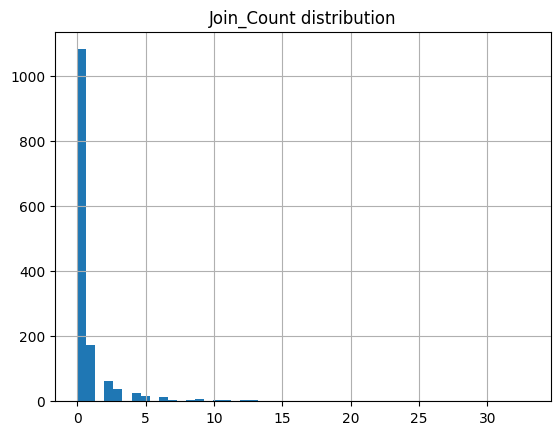

In [27]:
import matplotlib.pyplot as plt

print(y.describe())
print(f"Skewness: {y.skew():.2f}")
y.hist(bins=50)
plt.title("Join_Count distribution")
plt.show()

In [28]:
print(X_final.isnull().sum()[X_final.isnull().sum() > 0])

Series([], dtype: int64)


In [29]:
y_binary = (y > 0).astype(int)

print(y_binary.value_counts())
print(f"Class balance: {y_binary.mean():.2%} positive")

Join_Count
0    1083
1     365
Name: count, dtype: int64
Class balance: 25.21% positive


In [30]:
rename_map = {
    'CRMCYBURG': 'burglary_crime_est',
    'CRMCYTOTC': 'total_crime_est',
    'TOTPOP_CY': 'total_population',
    'UNEMPRT_CY_I': 'unemployment_rate_idx',
    'HISPPOP_CY_P': 'pct_hispanic',
    'MEDHINC_CY_I': 'median_income_idx',
    'ACSVET_P': 'pct_veterans',
    'ACSVET_P_1': 'pct_veterans_2',
    'ACSHSGRAD_P': 'pct_hs_grad',
    'ACS35NOHI_P': 'pct_no_health_insurance',
    'ACSEDNOSCH_P': 'pct_no_schooling',
    'ACSGRNTI50_P': 'pct_severe_rent_burden',
    'ACSBLWPV_P': 'pct_below_poverty',
    'ACSPUBAI_P': 'pct_public_assistance',
    'ACSHHDIS_P': 'pct_household_disability',
    'X14068_X_I': 'esri_market_idx_14068',
    'X14068FY_X_I': 'esri_market_idx_14068_forecast',
}

X_final = X_final.rename(columns=rename_map)
print(X_final.columns.tolist())

['2024 Total Crime Index', '2024 Total Population', '2024 Unemployment Rate: Index', '2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent', '2023 HHs w/Public Assist Income (ACS 5-Yr): Percent', '2023 Pop w/Income Below Poverty Level (ACS 5-Yr): Percent', '2023 HHs/Gross Rent 50+% of Income (ACS 5-Yr): Percent', '2023 Pop 25+: No Schooling (ACS 5-Yr): Percent', '2023 Pop 35-64: No Health Insurance (ACS 5-Yr): Percent', '2023 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent', '2023 Pop 25+: HS Diploma (ACS 5-Yr): Percent', '2030 Value of Credit Card Debt: Index', 'total_crime_est', 'total_population', 'burglary_crime_est', 'unemployment_rate_idx', 'pct_household_disability', 'pct_public_assistance', 'pct_below_poverty', 'pct_severe_rent_burden', 'pct_no_schooling', 'pct_no_health_insurance', 'pct_veterans_2', 'pct_hs_grad', 'esri_market_idx_14068_forecast', 'hospital_count', 'fire_station_count', 'library_count', 'college_count', 'public_school_count', 'private_school_count', 'recreatio

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Tents       0.83      0.67      0.74      1083
       Tents       0.38      0.59      0.46       365

    accuracy                           0.65      1448
   macro avg       0.60      0.63      0.60      1448
weighted avg       0.71      0.65      0.67      1448

AUC-ROC: 0.6961


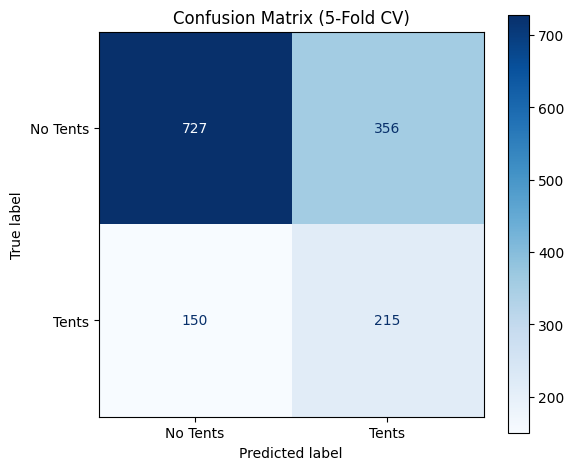

/usr/local/lib/python3.13/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)



SHAP SUMMARY PLOT


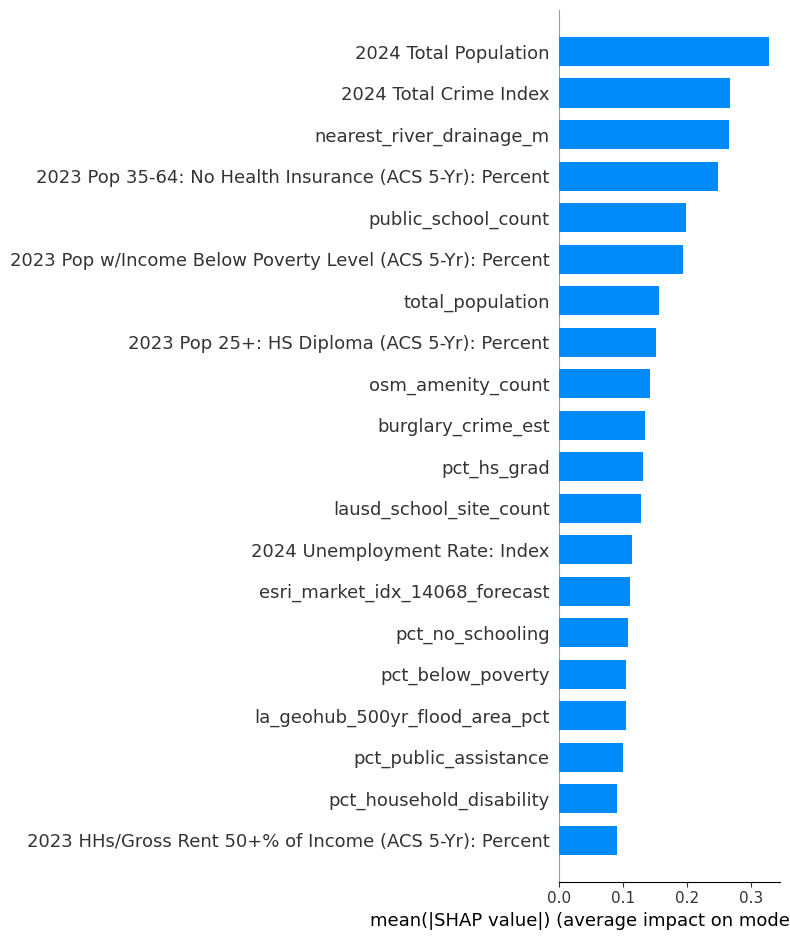

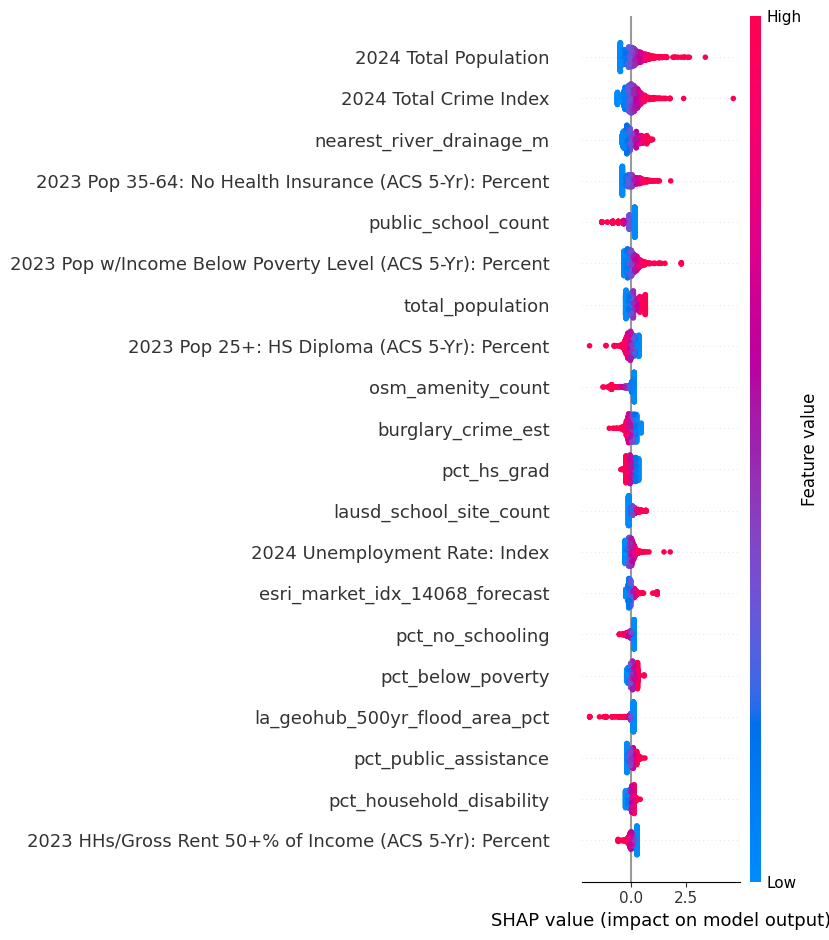

In [31]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
import shap
import matplotlib.pyplot as plt

# X_final contains the selected and cleaned numerical features.
# df_id_coords was captured in an earlier cell (DGZ2WSAkmHAC) and contains
# GRID_ID_x, GRID_ID_y, latitude, longitude.

# Separate numerical features for scaling (X_final should already be clean)
X_numerical_for_scaling = X_final.copy()

# ── 1. Standardize numerical features────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_numerical_for_scaling),
    columns=X_numerical_for_scaling.columns,
    index=X_numerical_for_scaling.index
)

# Create a final DataFrame for user output, combining scaled numerical and non-scaled identifier columns
# df_id_coords is expected to be globally available and properly indexed from an earlier step.
final_df_for_user_output = pd.concat([X_scaled, df_id_coords], axis=1)

# ── 2. Model + CV setup (using only scaled numerical features) ───────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# ── 3. CV Predictions (for metrics) ──────────────────────────────────────────
y_pred  = cross_val_predict(model, X_scaled, y_binary, cv=cv, method='predict')
y_proba = cross_val_predict(model, X_scaled, y_binary, cv=cv, method='predict_proba')[:, 1]

# ── 4. Metrics ────────────────────────────────────────────────────────────────
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_binary, y_pred, target_names=['No Tents', 'Tents']))

print(f"AUC-ROC: {roc_auc_score(y_binary, y_proba):.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_binary, y_pred,
    display_labels=['No Tents', 'Tents'],
    cmap='Blues', ax=ax
)
plt.title("Confusion Matrix (5-Fold CV)")
plt.tight_layout()
plt.show()

# ── 5. SHAP ───────────────────────────────────────────────────────────────────
# Fit on full data for SHAP
model.fit(X_scaled, y_binary)

explainer   = shap.LinearExplainer(model, X_scaled, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_scaled)

print("\n" + "=" * 50)
print("SHAP SUMMARY PLOT")
print("=" * 50)
shap.summary_plot(shap_values, X_scaled, plot_type="bar", max_display=20)
shap.summary_plot(shap_values, X_scaled, max_display=20) # beeswarm


In [32]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to be scaled (excluding identifiers/coordinates)
numerical_cols_to_scale = df_25_feature.select_dtypes(include=['number']).columns.tolist()

# Remove 'Join_Count' (target variable) from numerical columns to scale
if 'Join_Count' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('Join_Count')

# Exclude any other columns that might have slipped through and are not meant to be scaled (e.g., from df_id_coords if it was accidentally recreated)
for col in ['GRID_ID_x', 'GRID_ID_y', 'latitude', 'longitude']:
    if col in numerical_cols_to_scale:
        numerical_cols_to_scale.remove(col)

# Create a DataFrame with only the features to be scaled
X_to_scale = df_25_feature[numerical_cols_to_scale].copy()

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_scaled_only = pd.DataFrame(
    scaler.fit_transform(X_to_scale),
    columns=X_to_scale.columns,
    index=X_to_scale.index
)

# Re-add the 'Join_Count' column (if it exists and was removed) to the scaled features
if 'Join_Count' in df_25_feature.columns:
    X_scaled_only['Join_Count'] = df_25_feature['Join_Count']

# Concatenate the scaled numerical features with the non-scaled identifier/coordinate columns
# Ensure the indices align correctly
final_output_df = pd.concat([X_scaled_only, df_id_coords], axis=1)

print("Final DataFrame with scaled features and original identifiers/coordinates:")
display(final_output_df.head())
print(f"Shape of final_output_df: {final_output_df.shape}")
print("Info of final_output_df:")
final_output_df.info()

Final DataFrame with scaled features and original identifiers/coordinates:


,2024 Total Crime Index,2024 Total Population,2024 Burglary Index,2024 Unemployment Rate: Index,2024 Hispanic Population: Percent,2022 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent,2024 Median Household Income: Index,2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent,2023 HHs w/Public Assist Income (ACS 5-Yr): Percent,2023 Pop w/Income Below Poverty Level (ACS 5-Yr): Percent,...,la_geohub_500yr_flood_intersects,la_geohub_fire_hazard_area_pct,la_geohub_fire_hazard_intersects,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,heat_exposure_proxy_score,Join_Count
0,-1.024172,-1.165922,-0.274723,-1.226298,-0.482808,3.437129,0.453241,-0.252898,-0.217766,-0.408614,...,0.858027,-4.769836,0.026288,0.235172,3.395070,-2.952112,-0.051458,1.967052,-2.882191,0
1,-1.293321,-0.674509,-0.370091,-0.226998,-0.322884,0.390836,0.092181,-0.358366,-1.052799,-1.040405,...,0.858027,-6.368301,0.026288,-0.045007,2.138947,-2.160697,0.100124,1.795985,-2.099236,0
2,-1.052503,-1.302722,-1.361920,-1.643727,-0.246239,4.535984,-0.667945,-2.030299,-1.052799,-1.326553,...,0.858027,-6.368301,0.026288,-0.045007,2.138947,-2.160697,0.100124,1.795985,-2.099236,0
3,-1.109166,-0.324262,-0.312871,-0.467336,-0.189123,1.372376,0.130187,-0.746525,-0.115062,-0.517218,...,0.858027,-9.813055,0.026288,-0.564611,-0.538122,-3.434475,13.842683,1.005580,-3.311553,0
4,-1.335819,-0.140406,-0.732490,-1.251597,-0.416849,2.064537,0.301216,-0.224370,-0.854088,-0.231071,...,-1.165464,0.149471,0.026288,0.311584,1.617865,-1.581983,-0.107980,1.338974,-1.553694,0


Shape of final_output_df: (1448, 83)
Info of final_output_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1448 entries, 0 to 1447
Data columns (total 83 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   2024 Total Crime Index                                     1448 non-null   float64
 1   2024 Total Population                                      1448 non-null   float64
 2   2024 Burglary Index                                        1448 non-null   float64
 3   2024 Unemployment Rate: Index                              1448 non-null   float64
 4   2024 Hispanic Population: Percent                          1448 non-null   float64
 5   2022 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent         1448 non-null   float64
 6   2024 Median Household Income: Index                        1448 non-null   float64
 7   2023 HHs w/1+ Persons w/Disability

In [33]:
# Download the final DataFrame
final_output_df.to_csv('final_processed_data.csv', index=False)
print("final_processed_data.csv has been downloaded.")

final_processed_data.csv has been downloaded.


In [34]:
final_output_df

,2024 Total Crime Index,2024 Total Population,2024 Burglary Index,2024 Unemployment Rate: Index,2024 Hispanic Population: Percent,2022 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent,2024 Median Household Income: Index,2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent,2023 HHs w/Public Assist Income (ACS 5-Yr): Percent,2023 Pop w/Income Below Poverty Level (ACS 5-Yr): Percent,...,la_geohub_500yr_flood_intersects,la_geohub_fire_hazard_area_pct,la_geohub_fire_hazard_intersects,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,heat_exposure_proxy_score,Join_Count
0,-1.024172,-1.165922,-0.274723,-1.226298,-0.482808,3.437129,0.453241,-0.252898,-0.217766,-0.408614,...,0.858027,-4.769836,0.026288,0.235172,3.395070,-2.952112,-0.051458,1.967052,-2.882191,0
1,-1.293321,-0.674509,-0.370091,-0.226998,-0.322884,0.390836,0.092181,-0.358366,-1.052799,-1.040405,...,0.858027,-6.368301,0.026288,-0.045007,2.138947,-2.160697,0.100124,1.795985,-2.099236,0
2,-1.052503,-1.302722,-1.361920,-1.643727,-0.246239,4.535984,-0.667945,-2.030299,-1.052799,-1.326553,...,0.858027,-6.368301,0.026288,-0.045007,2.138947,-2.160697,0.100124,1.795985,-2.099236,0
3,-1.109166,-0.324262,-0.312871,-0.467336,-0.189123,1.372376,0.130187,-0.746525,-0.115062,-0.517218,...,0.858027,-9.813055,0.026288,-0.564611,-0.538122,-3.434475,13.842683,1.005580,-3.311553,0
4,-1.335819,-0.140406,-0.732490,-1.251597,-0.416849,2.064537,0.301216,-0.224370,-0.854088,-0.231071,...,-1.165464,0.149471,0.026288,0.311584,1.617865,-1.581983,-0.107980,1.338974,-1.553694,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,-0.910846,-0.917547,-0.961374,-0.922713,1.103166,0.946129,0.947323,1.924764,0.632896,-0.942190,...,-1.165464,0.149471,0.026288,-0.050101,0.553180,-0.633012,0.115539,0.572293,-0.613307,0
1444,-1.038338,-0.618722,-0.866006,-0.555882,1.107588,0.957861,1.118351,1.369758,-0.050313,-0.815643,...,-1.165464,0.149471,0.026288,1.865302,2.202418,-2.174029,0.059017,1.764768,-2.206998,0
1445,-0.556701,-0.975760,-0.160282,-0.644427,0.995567,0.316536,0.282212,1.535741,-0.532578,-0.973354,...,-1.165464,0.149471,0.026288,4.193331,2.339599,-1.769232,0.208029,0.690916,-1.928333,0
1446,-1.845787,-1.312909,-2.163012,-1.643727,-1.650179,-1.052145,-2.112184,-2.030299,-1.052799,-1.326553,...,0.858027,0.149471,0.026288,-0.416880,1.143875,-1.495327,-0.118257,1.742293,-1.433304,0


In [35]:
final_df_for_user_output.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1448 entries, 0 to 1447
Data columns (total 53 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   2024 Total Crime Index                                     1448 non-null   float64
 1   2024 Total Population                                      1448 non-null   float64
 2   2024 Unemployment Rate: Index                              1448 non-null   float64
 3   2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent     1448 non-null   float64
 4   2023 HHs w/Public Assist Income (ACS 5-Yr): Percent        1448 non-null   float64
 5   2023 Pop w/Income Below Poverty Level (ACS 5-Yr): Percent  1448 non-null   float64
 6   2023 HHs/Gross Rent 50+% of Income (ACS 5-Yr): Percent     1448 non-null   float64
 7   2023 Pop 25+: No Schooling (ACS 5-Yr): Percent             1448 non-null   float64
 8   2023 Pop

In [36]:
y = (df_25_feature['Join_Count'] > 0).astype(int)
print(y.value_counts())

Join_Count
0    1083
1     365
Name: count, dtype: int64


In [37]:
# 1. Add interaction features for your top separators
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
X_enhanced = X_final.copy()
X_enhanced['pop_x_poverty']    = X_final['total_population'] * X_final['pct_below_poverty']
X_enhanced['pop_x_crime']      = X_final['total_population'] * X_final['total_crime_est']
X_enhanced['poverty_x_flood']  = X_final['pct_below_poverty'] * X_final['fema_flood_hazard_area_pct']

# 2. Rerun RF with enhanced features
scaler2  = StandardScaler()
X_enh_scaled = pd.DataFrame(scaler2.fit_transform(X_enhanced), columns=X_enhanced.columns)

rf2 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
y_proba2 = cross_val_predict(rf2, X_enh_scaled, y, cv=cv, method='predict_proba')[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_proba2)
y_pred2  = (y_proba2 >= thresholds[np.argmax(tpr - fpr)]).astype(int)
print(f"AUC: {roc_auc_score(y, y_proba2):.4f}")
print(classification_report(y, y_pred2, target_names=['No Tents', 'Tents']))

AUC: 0.7290
              precision    recall  f1-score   support

    No Tents       0.84      0.77      0.81      1083
       Tents       0.46      0.57      0.51       365

    accuracy                           0.72      1448
   macro avg       0.65      0.67      0.66      1448
weighted avg       0.75      0.72      0.73      1448



In [38]:
# See which features actually differ between classes
means = pd.DataFrame({
    'No Tents': X_final[y == 0].mean(),
    'Tents':    X_final[y == 1].mean(),
})
means['diff'] = (means['Tents'] - means['No Tents']).abs()
means['pct_diff'] = ((means['Tents'] - means['No Tents']) / (means['No Tents'] + 1e-9)).abs()
print(means.sort_values('diff', ascending=False).head(15))

                                                       No Tents        Tents  \
2024 Total Population                               2363.453370  3724.098630   
nearest_river_drainage_m                            1893.338116  2241.944274   
nearest_osm_major_road_m                             282.661662   309.930110   
2024 Total Crime Index                               123.716528   149.830137   
2024 Unemployment Rate: Index                        124.228994   146.906849   
nearest_freeway_m                                    906.701348   925.693973   
total_population                                    3972.425669  3986.328767   
2030 Value of Credit Card Debt: Index                109.678670    96.865753   
unemployment_rate_idx                                148.723915   159.520548   
total_crime_est                                      191.505078   183.504110   
2023 Pop w/Income Below Poverty Level (ACS 5-Yr...    12.521043    18.573890   
burglary_crime_est                      

In [39]:
print(X_final.columns.tolist())

['2024 Total Crime Index', '2024 Total Population', '2024 Unemployment Rate: Index', '2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent', '2023 HHs w/Public Assist Income (ACS 5-Yr): Percent', '2023 Pop w/Income Below Poverty Level (ACS 5-Yr): Percent', '2023 HHs/Gross Rent 50+% of Income (ACS 5-Yr): Percent', '2023 Pop 25+: No Schooling (ACS 5-Yr): Percent', '2023 Pop 35-64: No Health Insurance (ACS 5-Yr): Percent', '2023 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent', '2023 Pop 25+: HS Diploma (ACS 5-Yr): Percent', '2030 Value of Credit Card Debt: Index', 'total_crime_est', 'total_population', 'burglary_crime_est', 'unemployment_rate_idx', 'pct_household_disability', 'pct_public_assistance', 'pct_below_poverty', 'pct_severe_rent_burden', 'pct_no_schooling', 'pct_no_health_insurance', 'pct_veterans_2', 'pct_hs_grad', 'esri_market_idx_14068_forecast', 'hospital_count', 'fire_station_count', 'library_count', 'college_count', 'public_school_count', 'private_school_count', 'recreatio

In [40]:
print(X_final.columns.tolist())

['2024 Total Crime Index', '2024 Total Population', '2024 Unemployment Rate: Index', '2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent', '2023 HHs w/Public Assist Income (ACS 5-Yr): Percent', '2023 Pop w/Income Below Poverty Level (ACS 5-Yr): Percent', '2023 HHs/Gross Rent 50+% of Income (ACS 5-Yr): Percent', '2023 Pop 25+: No Schooling (ACS 5-Yr): Percent', '2023 Pop 35-64: No Health Insurance (ACS 5-Yr): Percent', '2023 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent', '2023 Pop 25+: HS Diploma (ACS 5-Yr): Percent', '2030 Value of Credit Card Debt: Index', 'total_crime_est', 'total_population', 'burglary_crime_est', 'unemployment_rate_idx', 'pct_household_disability', 'pct_public_assistance', 'pct_below_poverty', 'pct_severe_rent_burden', 'pct_no_schooling', 'pct_no_health_insurance', 'pct_veterans_2', 'pct_hs_grad', 'esri_market_idx_14068_forecast', 'hospital_count', 'fire_station_count', 'library_count', 'college_count', 'public_school_count', 'private_school_count', 'recreatio

In [41]:
"""
RF Teacher → SNN Student Pipeline (v2)
========================================
Implements both:
  - SNN-1: 1-layer Superposable Neural Network (additive, one subnet per feature)
  - SNN-2: 2-layer SNN with pairwise interaction subnets on top of SNN-1

Distilled from a Random Forest teacher via 5-fold CV soft labels.

Architecture overview:
  SNN-1:  P(y=1) = σ( Σ_j  S_j(x_j) )
  SNN-2:  P(y=1) = σ( Σ_j  S_j(x_j)  +  Σ_{j<k} I_{jk}(x_j, x_k) )

  where S_j  = SubNet1  (RBF -> linear, single feature)
        I_jk = SubNet2  (product RBF kernel, feature pair)
"""

import argparse, json, os, warnings, itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

# ── Feature configuration ─────────────────────────────────────────────────────
FEATURES = [
    # Esri raw socioeconomic
    "2024 Total Crime Index",
    "2024 Total Population",
    "2024 Unemployment Rate: Index",
    "2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent",
    "2023 HHs w/Public Assist Income (ACS 5-Yr): Percent",
    "2023 Pop w/Income Below Poverty Level (ACS 5-Yr): Percent",
    "2023 HHs/Gross Rent 50+% of Income (ACS 5-Yr): Percent",
    "2023 Pop 25+: No Schooling (ACS 5-Yr): Percent",
    "2023 Pop 35-64: No Health Insurance (ACS 5-Yr): Percent",
    "2023 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent",
    "2023 Pop 25+: HS Diploma (ACS 5-Yr): Percent",
    "2030 Value of Credit Card Debt: Index",
    # Derived socioeconomic
    "total_crime_est",
    "total_population",
    "burglary_crime_est",
    "unemployment_rate_idx",
    "pct_household_disability",
    "pct_public_assistance",
    "pct_below_poverty",
    "pct_severe_rent_burden",
    "pct_no_schooling",
    "pct_no_health_insurance",
    "pct_veterans_2",
    "pct_hs_grad",
    "esri_market_idx_14068_forecast",
    # Facilities / Services
    "hospital_count",
    "fire_station_count",
    "library_count",
    "college_count",
    "public_school_count",
    "private_school_count",
    "recreation_center_count",
    "adult_recreation_count",
    "affordable_housing_count",
    "sud_treatment_count",
    "police_station_count",
    "food_access_count",
    "lausd_school_site_count",
    # Roads / Waterways
    "nearest_osm_major_road_m",
    "freeway_segments_count",
    "nearest_freeway_m",
    "river_drainage_segments_count",
    "nearest_river_drainage_m",
    "osm_amenity_count",
    # Flood / Hazard
    "fema_flood_hazard_area_pct",
    "la_geohub_100yr_flood_intersects",
    "la_geohub_500yr_flood_area_pct",
    "la_geohub_500yr_flood_intersects",
    "la_geohub_fire_hazard_area_pct",
    # Land Cover
    "tree_canopy_proxy_pct",
    "water_proxy_pct",
    "bare_ground_proxy_pct",
    "dominant_landcover_class",
]

FEATURE_LABELS = {
    "2024 Total Crime Index":                                "Total Crime Index (Esri)",
    "2024 Total Population":                                 "Total Population (Esri)",
    "2024 Unemployment Rate: Index":                         "Unemployment Rate Idx (Esri)",
    "2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent":"Pct HH w/Disability (ACS)",
    "2023 HHs w/Public Assist Income (ACS 5-Yr): Percent":  "Pct HH Public Assist (ACS)",
    "2023 Pop w/Income Below Poverty Level (ACS 5-Yr): Percent":"Pct Below Poverty (ACS)",
    "2023 HHs/Gross Rent 50+% of Income (ACS 5-Yr): Percent":"Pct Severe Rent Burden (ACS)",
    "2023 Pop 25+: No Schooling (ACS 5-Yr): Percent":       "Pct No Schooling (ACS)",
    "2023 Pop 35-64: No Health Insurance (ACS 5-Yr): Percent":"Pct No Health Insurance (ACS)",
    "2023 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent":   "Pct Veterans (ACS)",
    "2023 Pop 25+: HS Diploma (ACS 5-Yr): Percent":         "Pct HS Diploma (ACS)",
    "2030 Value of Credit Card Debt: Index":                 "Credit Card Debt Idx (Esri)",
    "total_crime_est":                "Total Crime Est",
    "total_population":               "Total Population",
    "burglary_crime_est":             "Burglary Crime Est",
    "unemployment_rate_idx":          "Unemployment Rate Idx",
    "pct_household_disability":       "Pct HH Disability",
    "pct_public_assistance":          "Pct Public Assistance",
    "pct_below_poverty":              "Pct Below Poverty",
    "pct_severe_rent_burden":         "Pct Severe Rent Burden",
    "pct_no_schooling":               "Pct No Schooling",
    "pct_no_health_insurance":        "Pct No Health Insurance",
    "pct_veterans_2":                 "Pct Veterans",
    "pct_hs_grad":                    "Pct HS Grad",
    "esri_market_idx_14068_forecast": "Market Idx 14068 Forecast",
    "hospital_count":                 "Hospitals",
    "fire_station_count":             "Fire Stations",
    "library_count":                  "Libraries",
    "college_count":                  "Colleges",
    "public_school_count":            "Public Schools",
    "private_school_count":           "Private Schools",
    "recreation_center_count":        "Recreation Centers",
    "adult_recreation_count":         "Adult Recreation",
    "affordable_housing_count":       "Affordable Housing",
    "sud_treatment_count":            "SUD Treatment Sites",
    "police_station_count":           "Police Stations",
    "food_access_count":              "Food Access Sites",
    "lausd_school_site_count":        "LAUSD Schools",
    "nearest_osm_major_road_m":       "Nearest Major Road (m)",
    "freeway_segments_count":         "Freeway Segments",
    "nearest_freeway_m":              "Nearest Freeway (m)",
    "river_drainage_segments_count":  "River Drainage Segments",
    "nearest_river_drainage_m":       "Nearest River Drainage (m)",
    "osm_amenity_count":              "OSM Amenities",
    "fema_flood_hazard_area_pct":     "FEMA Flood Hazard Pct",
    "la_geohub_100yr_flood_intersects":"100yr Flood Intersects",
    "la_geohub_500yr_flood_area_pct": "500yr Flood Area Pct",
    "la_geohub_500yr_flood_intersects":"500yr Flood Intersects",
    "la_geohub_fire_hazard_area_pct": "Fire Hazard Area Pct",
    "tree_canopy_proxy_pct":          "Tree Canopy Pct",
    "water_proxy_pct":                "Water Pct",
    "bare_ground_proxy_pct":          "Bare Ground Pct",
    "dominant_landcover_class":       "Dominant Landcover Class",
}

TARGET_COL = "Join_Count"
ID_COL     = "OBJECTID"


# =============================================================================
# ARCHITECTURES
# =============================================================================

class SubNet1(nn.Module):
    def __init__(self, n_rbf: int = 10):
        super().__init__()
        self.centers    = nn.Parameter(torch.linspace(-2.5, 2.5, n_rbf))
        self.log_widths = nn.Parameter(torch.zeros(n_rbf))
        self.linear     = nn.Linear(n_rbf, 1, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x   = x.unsqueeze(1)
        c   = self.centers.unsqueeze(0)
        w   = torch.exp(self.log_widths).unsqueeze(0)
        rbf = torch.exp(-w * (x - c) ** 2)
        return self.linear(rbf).squeeze(1)

    def get_curve(self, x_range=(-3, 3), n_pts=200):
        xs = torch.linspace(*x_range, n_pts)
        with torch.no_grad():
            ys = self.forward(xs).numpy()
        return xs.numpy(), ys


class SubNet2(nn.Module):
    def __init__(self, n_rbf: int = 6):
        super().__init__()
        pts = torch.linspace(-2.5, 2.5, n_rbf)
        cj, ck = torch.meshgrid(pts, pts, indexing="ij")
        self.register_buffer("cj", cj.reshape(-1))
        self.register_buffer("ck", ck.reshape(-1))
        n_basis = n_rbf * n_rbf
        self.log_wj = nn.Parameter(torch.zeros(n_basis))
        self.log_wk = nn.Parameter(torch.zeros(n_basis))
        self.linear = nn.Linear(n_basis, 1, bias=True)

    def forward(self, xj: torch.Tensor, xk: torch.Tensor) -> torch.Tensor:
        wj  = torch.exp(self.log_wj)
        wk  = torch.exp(self.log_wk)
        phi = torch.exp(-wj * (xj.unsqueeze(1) - self.cj) ** 2) * \
              torch.exp(-wk * (xk.unsqueeze(1) - self.ck) ** 2)
        return self.linear(phi).squeeze(1)


# =============================================================================
# TRAINING: SNN-1
# =============================================================================

def train_snn1(X_np, soft_targets, hard_labels, n_rbf=10, n_rounds=4,
               epochs=500, lr=2e-3, verbose=True):
    n, n_feat = X_np.shape
    X_t = torch.tensor(X_np,         dtype=torch.float32)
    ts0 = torch.tensor(soft_targets, dtype=torch.float32)

    nets = [SubNet1(n_rbf) for _ in range(n_feat)]
    fo   = [torch.zeros(n) for _ in range(n_feat)]

    if verbose: print(f"  [SNN-1] Round 1/{n_rounds}: sequential distillation")
    residual = ts0.clone()
    for j, net in enumerate(nets):
        opt = torch.optim.Adam(net.parameters(), lr=lr)
        for _ in range(epochs):
            opt.zero_grad()
            nn.MSELoss()(net(X_t[:, j]), residual).backward()
            opt.step()
        with torch.no_grad():
            fo[j]    = net(X_t[:, j])
            residual = residual - fo[j]

    for rnd in range(1, n_rounds):
        lr_r = lr * (0.6 ** rnd)
        for j, net in enumerate(nets):
            others   = sum(fo[k].detach() for k in range(n_feat) if k != j)
            target_j = ts0 - others
            opt = torch.optim.Adam(net.parameters(), lr=lr_r)
            for _ in range(epochs):
                opt.zero_grad()
                nn.MSELoss()(net(X_t[:, j]), target_j).backward()
                opt.step()
            with torch.no_grad():
                fo[j] = net(X_t[:, j])
        if verbose:
            auc = roc_auc_score(
                hard_labels,
                torch.sigmoid(torch.stack(fo, 1).sum(1)).numpy()
            )
            print(f"  [SNN-1] Round {rnd+1}/{n_rounds}: AUC={auc:.4f}  lr={lr_r:.5f}")

    contribs = torch.stack(fo, 1).detach().numpy()
    probs    = torch.sigmoid(torch.tensor(contribs.sum(1), dtype=torch.float32)).numpy()
    return nets, contribs, probs


# =============================================================================
# TRAINING: SNN-2
# =============================================================================

def select_top_pairs(X_np, hard_labels, n_feat, top_k=20):
    print(f"  [SNN-2] Selecting top {top_k} pairs via RF interaction screen...")
    pairs    = list(itertools.combinations(range(n_feat), 2))
    products = np.column_stack([X_np[:, j] * X_np[:, k] for j, k in pairs])
    rf_screen = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)
    rf_screen.fit(products, hard_labels)
    ranked    = sorted(zip(pairs, rf_screen.feature_importances_), key=lambda x: -x[1])
    top_pairs = [p for p, _ in ranked[:top_k]]
    print(f"  [SNN-2] Top pair: {FEATURES[top_pairs[0][0]]} x {FEATURES[top_pairs[0][1]]}")
    return top_pairs


def train_snn2(X_np, soft_targets, hard_labels, snn1_contribs,
               top_pairs, n_rbf2=6, n_rounds=3, epochs=400, lr=1e-3, verbose=True):
    n    = X_np.shape[0]
    X_t  = torch.tensor(X_np,                dtype=torch.float32)
    ts0  = torch.tensor(soft_targets,         dtype=torch.float32)
    base = torch.tensor(snn1_contribs.sum(1), dtype=torch.float32)

    pair_nets = {jk: SubNet2(n_rbf2) for jk in top_pairs}
    pair_fo   = {jk: torch.zeros(n)  for jk in top_pairs}

    if verbose: print(f"  [SNN-2] Round 1/{n_rounds}: sequential interaction distillation")
    residual = ts0 - base
    for jk in top_pairs:
        j, k = jk
        net  = pair_nets[jk]
        opt  = torch.optim.Adam(net.parameters(), lr=lr)
        for _ in range(epochs):
            opt.zero_grad()
            nn.MSELoss()(net(X_t[:, j], X_t[:, k]), residual).backward()
            opt.step()
        with torch.no_grad():
            pair_fo[jk] = net(X_t[:, j], X_t[:, k])
            residual     = residual - pair_fo[jk]

    for rnd in range(1, n_rounds):
        lr_r = lr * (0.5 ** rnd)
        for jk in top_pairs:
            j, k   = jk
            others = sum(pair_fo[p].detach() for p in top_pairs if p != jk)
            target = ts0 - base - others
            opt    = torch.optim.Adam(pair_nets[jk].parameters(), lr=lr_r)
            for _ in range(epochs):
                opt.zero_grad()
                nn.MSELoss()(pair_nets[jk](X_t[:, j], X_t[:, k]), target).backward()
                opt.step()
            with torch.no_grad():
                pair_fo[jk] = pair_nets[jk](X_t[:, j], X_t[:, k])
        if verbose:
            total = base + sum(pair_fo[p].detach() for p in top_pairs)
            auc   = roc_auc_score(hard_labels, torch.sigmoid(total).numpy())
            print(f"  [SNN-2] Round {rnd+1}/{n_rounds}: AUC={auc:.4f}  lr={lr_r:.5f}")

    pair_contribs = np.column_stack([pair_fo[jk].detach().numpy() for jk in top_pairs])
    probs         = 1 / (1 + np.exp(-(base.numpy() + pair_contribs.sum(1))))
    return pair_nets, pair_contribs, probs


# =============================================================================
# HELPERS
# =============================================================================

def optimal_threshold(y, probs):
    fpr, tpr, thresholds = roc_curve(y, probs)
    return float(thresholds[np.argmax(tpr - fpr)])


def build_feature_summary(features, contribs, y, rf):
    delta    = contribs[y == 1].mean(0) - contribs[y == 0].mean(0)
    mean_abs = np.abs(contribs).mean(0)
    return pd.DataFrame({
        "feature":       features,
        "label":         [FEATURE_LABELS.get(f, f) for f in features],
        "rf_importance": rf.feature_importances_,
        "mean_abs_sj":   mean_abs,
        "delta_sj":      delta,
    }).sort_values("delta_sj", ascending=False).reset_index(drop=True)


def build_interaction_summary(top_pairs, pair_contribs, y, features):
    rows = []
    for idx, (j, k) in enumerate(top_pairs):
        col = pair_contribs[:, idx]
        rows.append({
            "feature_j":    features[j],
            "feature_k":    features[k],
            "label_j":      FEATURE_LABELS.get(features[j], features[j]),
            "label_k":      FEATURE_LABELS.get(features[k], features[k]),
            "mean_abs_Ijk": np.abs(col).mean(),
            "delta_Ijk":    col[y == 1].mean() - col[y == 0].mean(),
        })
    return pd.DataFrame(rows).sort_values("delta_Ijk", ascending=False).reset_index(drop=True)


def build_hex_output_snn1(ids, y, probs, contribs, features, thresh):
    contrib_df = pd.DataFrame(contribs, columns=[f"Sj_{f}" for f in features])
    return pd.concat([
        pd.Series(ids.values,                    name="hex_id"),
        pd.Series(y,                             name="tent_present"),
        pd.Series(probs,                         name="snn1_prob"),
        pd.Series((probs >= thresh).astype(int), name="snn1_pred"),
        contrib_df,
    ], axis=1)


def build_hex_output_snn2(ids, y, probs, snn1_contribs, pair_contribs,
                           features, top_pairs, thresh):
    snn1_df = pd.DataFrame(snn1_contribs, columns=[f"Sj_{f}" for f in features])
    pair_df = pd.DataFrame(
        {f"Ijk_{features[j]}_{features[k]}": pair_contribs[:, idx]
         for idx, (j, k) in enumerate(top_pairs)}
    )
    return pd.concat([
        pd.Series(ids.values,                    name="hex_id"),
        pd.Series(y,                             name="tent_present"),
        pd.Series(probs,                         name="snn2_prob"),
        pd.Series((probs >= thresh).astype(int), name="snn2_pred"),
        snn1_df, pair_df,
    ], axis=1)


def extract_curves_snn1(nets, features, X_raw):
    curves = {}
    for j, (f, net) in enumerate(zip(features, nets)):
        xs, ys = net.get_curve(x_range=(-3.0, 3.0), n_pts=200)
        x_raw  = np.linspace(float(X_raw[f].min()), float(X_raw[f].max()), 200)
        curves[f] = {
            "label": FEATURE_LABELS.get(f, f),
            "x_std": xs.tolist(),
            "x_raw": x_raw.tolist(),
            "y":     ys.tolist(),
        }
    return curves


def print_results(label, rf_auc, model_auc, model_ap, thresh, report):
    print("\n" + "=" * 60)
    print(f"RESULTS - {label}")
    print("=" * 60)
    print(f"  RF teacher AUC (CV):  {rf_auc:.4f}")
    print(f"  {label} AUC:          {model_auc:.4f}")
    print(f"  {label} AP:           {model_ap:.4f}")
    print(f"  Optimal threshold:    {thresh:.3f}")
    print()
    print(report)


def print_feature_table(summary):
    print("-- Feature contributions (dSj = tent - no-tent) ----------")
    print(f"{'#':<3} {'Feature':<35} {'dSj':>8}  direction")
    print("-" * 60)
    for i, row in summary.iterrows():
        bar = ("^" if row["delta_sj"] > 0 else "v") * min(int(abs(row["delta_sj"]) / 0.005), 20)
        print(f"{i+1:<3} {row['label']:<35} {row['delta_sj']:>+8.4f}  {bar}")


def print_interaction_table(inter_summary, top_n=15):
    print(f"\n-- Top interaction contributions (dI_jk) ----------------")
    print(f"{'#':<3} {'Pair':<50} {'dIjk':>8}")
    print("-" * 65)
    for i, row in inter_summary.head(top_n).iterrows():
        pair = f"{row['label_j']} x {row['label_k']}"
        print(f"{i+1:<3} {pair:<50} {row['delta_Ijk']:>+8.4f}")


# =============================================================================
# MAIN
# =============================================================================

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data",      default="/content/quarter_variables_and_tents_geo_enriched.csv")
    parser.add_argument("--out",       default="outputs")
    parser.add_argument("--rbf",       type=int,   default=10)
    parser.add_argument("--rbf2",      type=int,   default=6)
    parser.add_argument("--rounds",    type=int,   default=4)
    parser.add_argument("--rounds2",   type=int,   default=3)
    parser.add_argument("--epochs",    type=int,   default=500)
    parser.add_argument("--epochs2",   type=int,   default=400)
    parser.add_argument("--lr",        type=float, default=2e-3)
    parser.add_argument("--lr2",       type=float, default=1e-3)
    parser.add_argument("--top_pairs", type=int,   default=20)
    args, _ = parser.parse_known_args()

    os.makedirs(args.out, exist_ok=True)

    # ── Load ──────────────────────────────────────────────────────────────────
    try:
        X   = X_final[FEATURES].fillna(0).reset_index(drop=True)
        y   = y_binary.values if hasattr(y_binary, "values") else np.array(y_binary)
        ids = pd.Series(range(len(X)))
        print(f"\nUsing in-memory X_final / y_binary ({len(X)} hexes)")
    except NameError:
        print(f"\nLoading: {args.data}")
        df  = pd.read_csv(args.data)
        X   = df[FEATURES].fillna(0)
        y   = (df[TARGET_COL] > 0).astype(int).values
        ids = df[ID_COL] if ID_COL in df.columns else pd.Series(range(len(df)))

    print(f"  {len(X)} hexes | {len(FEATURES)} features | "
          f"{y.sum()} tent-present ({y.mean()*100:.1f}%)")

    # ── Scale ─────────────────────────────────────────────────────────────────
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── RF Teacher ────────────────────────────────────────────────────────────
    print("\nStep 1: RF teacher (5-fold CV soft labels)...")
    rf = RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        max_depth=8, random_state=42, n_jobs=-1,
    )
    cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    soft_labels = cross_val_predict(rf, X_scaled, y, cv=cv, method="predict_proba")[:, 1]
    rf.fit(X_scaled, y)
    rf_auc = roc_auc_score(y, soft_labels)
    print(f"  RF AUC (CV): {rf_auc:.4f}")

    # =========================================================================
    # SNN-1
    # =========================================================================
    print(f"\nStep 2: SNN-1 distillation "
          f"(rbf={args.rbf}, rounds={args.rounds}, epochs={args.epochs})...")
    nets1, contribs1, probs1 = train_snn1(
        X_scaled, soft_labels, y,
        n_rbf=args.rbf, n_rounds=args.rounds,
        epochs=args.epochs, lr=args.lr, verbose=True,
    )

    thresh1  = optimal_threshold(y, probs1)
    auc1     = roc_auc_score(y, probs1)
    ap1      = average_precision_score(y, probs1)
    preds1   = (probs1 >= thresh1).astype(int)
    report1  = classification_report(y, preds1, target_names=["no tent", "tent"])
    summary1 = build_feature_summary(FEATURES, contribs1, y, rf)

    print_results("SNN-1", rf_auc, auc1, ap1, thresh1, report1)
    print_feature_table(summary1)

    hex1    = build_hex_output_snn1(ids, y, probs1, contribs1, FEATURES, thresh1)
    curves1 = extract_curves_snn1(nets1, FEATURES, X)

    summary1.to_csv(f"{args.out}/snn1_feature_summary.csv",   index=False)
    hex1.to_csv(    f"{args.out}/snn1_hex_contributions.csv", index=False)
    with open(f"{args.out}/snn1_curves.json", "w") as fh:
        json.dump(curves1, fh)
    with open(f"{args.out}/snn1_metrics.txt", "w") as fh:
        fh.write(f"RF teacher AUC (CV): {rf_auc:.4f}\n")
        fh.write(f"SNN-1 AUC:           {auc1:.4f}\n")
        fh.write(f"SNN-1 AP:            {ap1:.4f}\n")
        fh.write(f"Optimal threshold:   {thresh1:.3f}\n\n")
        fh.write(report1)
    torch.save({
        "nets":         [n.state_dict() for n in nets1],
        "scaler_mean":  scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
        "features":     FEATURES,
        "threshold":    thresh1,
        "n_rbf":        args.rbf,
    }, f"{args.out}/snn_model1.pt")

    # =========================================================================
    # SNN-2
    # =========================================================================
    print(f"\nStep 3: SNN-2 - selecting top {args.top_pairs} pairwise interactions...")
    top_pairs = select_top_pairs(X_scaled, y, len(FEATURES), top_k=args.top_pairs)

    print(f"\nStep 4: SNN-2 interaction distillation "
          f"(rbf2={args.rbf2}, rounds={args.rounds2}, epochs={args.epochs2})...")
    pair_nets, pair_contribs, probs2 = train_snn2(
        X_scaled, soft_labels, y, contribs1,
        top_pairs, n_rbf2=args.rbf2, n_rounds=args.rounds2,
        epochs=args.epochs2, lr=args.lr2, verbose=True,
    )

    thresh2   = optimal_threshold(y, probs2)
    auc2      = roc_auc_score(y, probs2)
    ap2       = average_precision_score(y, probs2)
    preds2    = (probs2 >= thresh2).astype(int)
    report2   = classification_report(y, preds2, target_names=["no tent", "tent"])
    summary2  = build_feature_summary(FEATURES, contribs1, y, rf)
    inter_sum = build_interaction_summary(top_pairs, pair_contribs, y, FEATURES)

    print_results("SNN-2", rf_auc, auc2, ap2, thresh2, report2)
    print_feature_table(summary2)
    print_interaction_table(inter_sum)
    print(f"\n  AUC lift SNN-1 -> SNN-2: {auc1:.4f} -> {auc2:.4f} "
          f"({(auc2-auc1)*100:+.2f} pp)")

    hex2 = build_hex_output_snn2(
        ids, y, probs2, contribs1, pair_contribs, FEATURES, top_pairs, thresh2
    )
    summary2.to_csv(  f"{args.out}/snn2_feature_summary.csv",    index=False)
    inter_sum.to_csv( f"{args.out}/snn2_interaction_summary.csv", index=False)
    hex2.to_csv(      f"{args.out}/snn2_hex_contributions.csv",   index=False)
    with open(f"{args.out}/snn2_metrics.txt", "w") as fh:
        fh.write(f"RF teacher AUC (CV): {rf_auc:.4f}\n")
        fh.write(f"SNN-1 AUC:           {auc1:.4f}\n")
        fh.write(f"SNN-2 AUC:           {auc2:.4f}\n")
        fh.write(f"SNN-2 AP:            {ap2:.4f}\n")
        fh.write(f"Optimal threshold:   {thresh2:.3f}\n\n")
        fh.write(report2)
    torch.save({
        "snn1_nets":    [n.state_dict() for n in nets1],
        "pair_nets":    {str(k): v.state_dict() for k, v in pair_nets.items()},
        "top_pairs":    top_pairs,
        "scaler_mean":  scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
        "features":     FEATURES,
        "threshold":    thresh2,
        "n_rbf":        args.rbf,
        "n_rbf2":       args.rbf2,
    }, f"{args.out}/snn_model2.pt")

    print("\n" + "=" * 60)
    print("ALL OUTPUTS")
    print("=" * 60)
    for fname in [
        "snn1_feature_summary.csv", "snn1_hex_contributions.csv",
        "snn1_curves.json", "snn1_metrics.txt", "snn_model1.pt",
        "snn2_feature_summary.csv", "snn2_interaction_summary.csv",
        "snn2_hex_contributions.csv", "snn2_metrics.txt", "snn_model2.pt",
    ]:
        print(f"  -> {args.out}/{fname}")


if __name__ == "__main__":
    main()


Using in-memory X_final / y_binary (1448 hexes)
  1448 hexes | 53 features | 365 tent-present (25.2%)

Step 1: RF teacher (5-fold CV soft labels)...
  RF AUC (CV): 0.7423

Step 2: SNN-1 distillation (rbf=10, rounds=4, epochs=500)...
  [SNN-1] Round 1/4: sequential distillation
  [SNN-1] Round 2/4: AUC=0.7639  lr=0.00120
  [SNN-1] Round 3/4: AUC=0.7692  lr=0.00072
  [SNN-1] Round 4/4: AUC=0.7721  lr=0.00043

RESULTS - SNN-1
  RF teacher AUC (CV):  0.7423
  SNN-1 AUC:          0.7721
  SNN-1 AP:           0.5527
  Optimal threshold:    0.600

              precision    recall  f1-score   support

     no tent       0.87      0.75      0.80      1083
        tent       0.47      0.65      0.55       365

    accuracy                           0.73      1448
   macro avg       0.67      0.70      0.67      1448
weighted avg       0.77      0.73      0.74      1448

-- Feature contributions (dSj = tent - no-tent) ----------
#   Feature                                  dSj  direction
------

In [ ]:
## half

In [44]:
df_sample = pd.read_csv('/content/outputLayer_0 9.csv')

In [45]:
df_50 = pd.read_csv('/content/half_variables_and_tents_geo_enriched.csv')

In [46]:
df_50 = pd.merge(df_sample,df_50,on = 'OBJECTID',how='inner' )

In [47]:
df_50

,OBJECTID,Join_Count_x,TARGET_FID_x,GRID_ID_x,Join_Count_y,TARGET_FID_y,JOIN_FID,GRID_ID_y,ID,sourceCountry,...,la_geohub_fire_hazard_intersects,heat_exposure_area_pct,heat_exposure_intersects,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,dominant_landcover_class,heat_exposure_proxy_score
0,1,0,1,AD-58,0,1,-1,AD-58,0,US,...,1,0.0,0,2.18,39.19,31.00,1.09,28.71,5,51.05
1,2,0,2,AE-58,1,2,1522,AE-58,1,US,...,1,0.0,0,1.07,29.61,34.33,3.43,32.62,5,53.71
2,3,0,3,AD-57,1,2,1524,AE-58,1,US,...,1,0.0,0,1.07,29.61,34.33,3.43,32.62,5,53.71
3,4,0,4,AE-57,0,3,-1,AD-57,2,US,...,1,0.0,0,1.41,16.99,67.25,0.97,14.79,5,76.65
4,5,0,5,AF-57,0,4,-1,AE-57,3,US,...,1,0.0,0,1.32,20.53,44.85,13.57,21.06,5,61.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762,763,1,763,O-2,1,300,219,AL-23,28,US,...,1,0.0,0,11.76,43.11,35.73,5.44,15.72,5,51.48
763,764,0,764,P-2,0,301,-1,AN-30,31,US,...,1,0.0,0,0.26,10.89,71.99,0.79,16.33,5,80.32
764,765,0,765,Q-2,0,302,-1,D-16,29,US,...,1,0.0,0,3.68,19.00,59.63,5.52,15.85,5,70.64
765,766,0,766,R-2,1,303,763,P-29,32,US,...,1,0.0,0,2.41,16.95,60.50,1.20,21.34,5,71.63


In [48]:
## Taking required features
df_50_feature = df_50.drop(['OBJECTID','TARGET_FID_x','Join_Count_y','TARGET_FID_y','JOIN_FID','GRID_ID_x','GRID_ID_y','ID','sourceCountry','ENRICH_FID','aggregationMethod','populationToPolygonSizeRating','apportionmentConfidence','HasData','ID_1','sourceCountry_1','ENRICH_FID_1','populationToPolygonSizeRating_1','aggregationMethod_1','populationToPolygonSizeRating_1','HasData_1','source_run','latitude','longitude','address','heading','filename','tent_prediction_count','max_conf','classes_seen','tent_ref_max_conf','tent_ref_mean_conf'],axis=1)

In [49]:
df_50_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 72 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Join_Count_x                      767 non-null    int64  
 1   CRMCYBURG                         767 non-null    int64  
 2   CRMCYTOTC                         767 non-null    int64  
 3   TOTPOP_CY                         767 non-null    int64  
 4   UNEMPRT_CY_I                      767 non-null    int64  
 5   HISPPOP_CY_P                      767 non-null    float64
 6   MEDHINC_CY_I                      767 non-null    int64  
 7   ACSVET_P                          767 non-null    float64
 8   apportionmentConfidence_1         767 non-null    float64
 9   X14068_X_I                        767 non-null    int64  
 10  X14068FY_X_I                      767 non-null    int64  
 11  ACSHSGRAD_P                       767 non-null    float64
 12  ACSVET_P

In [ ]:
zero_variance_columns = df_50_feature.columns[df_50_feature.var() == 0]
all_zeros_columns = df_50_feature.columns[(df_50_feature == 0).all()]

print("Columns with zero variance:")
print(zero_variance_columns.tolist())

print("\nColumns with all zeros:")
print(all_zeros_columns.tolist())

Columns with zero variance:
['tent_ref_point_count', 'tent_ref_prediction_sum', 'cool_zone_count', 'la_geohub_fire_hazard_intersects', 'heat_exposure_area_pct', 'heat_exposure_intersects']

Columns with all zeros:
['tent_ref_point_count', 'tent_ref_prediction_sum', 'cool_zone_count', 'heat_exposure_area_pct', 'heat_exposure_intersects']


In [ ]:
## drop columns with zero variance
columns_to_drop = list(set(zero_variance_columns.tolist() + all_zeros_columns.tolist()))
df_50_feature = df_50_feature.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
display(df_50_feature.head())

Dropped columns: ['tent_ref_prediction_sum', 'heat_exposure_area_pct', 'heat_exposure_intersects', 'la_geohub_fire_hazard_intersects', 'cool_zone_count', 'tent_ref_point_count']


,Join_Count_x,CRMCYBURG,CRMCYTOTC,TOTPOP_CY,UNEMPRT_CY_I,HISPPOP_CY_P,MEDHINC_CY_I,ACSVET_P,apportionmentConfidence_1,X14068_X_I,...,la_geohub_500yr_flood_area_pct,la_geohub_500yr_flood_intersects,la_geohub_fire_hazard_area_pct,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,dominant_landcover_class,heat_exposure_proxy_score
0,0,85,44,1580,43,31.77,137,9.34,2.576,124,...,0.43,1,74.16,2.18,39.19,31.00,1.09,28.71,5,51.05
1,0,84,35,1620,93,34.01,120,4.81,2.576,118,...,1.08,1,31.66,1.07,29.61,34.33,3.43,32.62,5,53.71
2,0,84,35,1620,93,34.01,120,4.81,2.576,118,...,1.08,1,31.66,1.07,29.61,34.33,3.43,32.62,5,53.71
3,0,105,62,8403,69,47.41,105,4.13,2.576,91,...,0.00,0,100.00,1.41,16.99,67.25,0.97,14.79,5,76.65
4,0,72,37,3175,64,35.78,116,9.34,2.576,100,...,4.34,1,85.14,1.32,20.53,44.85,13.57,21.06,5,61.00


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add a constant to the DataFrame for VIF calculation
X = add_constant(df_50_feature)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF values, sorting by VIF in descending order
print("VIF values after dropping 'ACSEDNOSCH' column:")
display(vif_data.sort_values(by='VIF', ascending=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


VIF values after dropping 'ACSEDNOSCH' column:


,feature,VIF
61,impervious_proxy_pct,3.100375e+07
65,heat_exposure_proxy_score,2.354411e+07
60,vegetation_proxy_pct,4.698620e+06
63,bare_ground_proxy_pct,2.561632e+06
62,water_proxy_pct,7.665615e+05
...,...,...
21,climate_tmax_2024_c,1.311616e-08
22,climate_ppt_2024_mm,1.200728e-08
20,climate_t2m_2024_c,0.000000e+00
8,apportionmentConfidence_1,0.000000e+00


In [ ]:
# 1. Re-run the function definition
def iterative_vif_drop(df, threshold=10):
    cols = list(df.columns)
    dropped = []

    while True:
        vif_df = pd.DataFrame({
            "feature": cols,
            "VIF": [variance_inflation_factor(df[cols].values, i)
                    for i in range(len(cols))]
        }).sort_values("VIF", ascending=False)

        max_vif = vif_df.iloc[0]["VIF"]
        if max_vif <= threshold:
            break

        drop_col = vif_df.iloc[0]["feature"]
        print(f"Dropping {drop_col} (VIF={max_vif:.1f})")
        dropped.append({"feature": drop_col, "VIF_at_drop": max_vif})
        cols.remove(drop_col)

    return cols, vif_df, pd.DataFrame(dropped)

# 2. Then call it
y = df_50_feature['Join_Count_x']
X = df_50_feature.drop(columns=['Join_Count_x'])

surviving_cols, final_vif_df, drop_log = iterative_vif_drop(X, threshold=10)

X_clean = X[surviving_cols]
print(final_vif_df)
print(f"\nDropped {len(drop_log)} features:")
print(drop_log)


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Dropping impervious_proxy_pct (VIF=30749926.9)


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Dropping heat_exposure_proxy_score (VIF=8096183.3)


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


...

Dropping ACSVET_P_1 (VIF=12.2)


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Dropping HISPPOP_CY_P (VIF=12.0)


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


                             feature       VIF
36            freeway_segments_count  8.584205
43         caltrans_highway_length_m  8.541356
4                       MEDHINC_CY_I  8.441702
52              vegetation_proxy_pct  8.135545
34     osm_major_road_segments_count  7.317686
40          nearest_river_drainage_m  7.212553
7                       X14068FY_X_I  6.909293
50    la_geohub_fire_hazard_area_pct  6.354162
0                          CRMCYBURG  6.300807
1                          CRMCYTOTC  6.237185
42   caltrans_highway_segments_count  5.645213
54             bare_ground_proxy_pct  4.739944
41                 osm_amenity_count  4.646139
30              business_sites_count  4.565830
49  la_geohub_500yr_flood_intersects  4.533153
45      fema_flood_hazard_intersects  4.508329
9                        ACS35NOHI_P  4.493421
19               transit_stops_count  4.354161
39           river_drainage_length_m  4.296549
51             tree_canopy_proxy_pct  4.222539
2            

In [ ]:
import numpy as np

def drop_high_corr(df, threshold=0.7):
    corr_matrix = df.corr().abs()
    dropped_corr = []

    cols = list(df.columns)

    while True:
        corr_matrix = df[cols].corr().abs()

        # Get upper triangle pairs above threshold
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr_pairs = [(col, row, upper.loc[row, col])
                          for col in upper.columns
                          for row in upper.index
                          if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > threshold]

        if not high_corr_pairs:
            break

        # Find all cols involved in high corr pairs
        flagged = set()
        for c1, c2, _ in high_corr_pairs:
            flagged.update([c1, c2])

        # Drop the one with highest avg correlation to all other variables
        avg_corr = corr_matrix[list(flagged)].mean(axis=0)
        drop_col = avg_corr.idxmax()

        print(f"Dropping {drop_col} (avg_corr={avg_corr[drop_col]:.3f})")
        dropped_corr.append({"feature": drop_col, "avg_corr_at_drop": avg_corr[drop_col]})
        cols.remove(drop_col)

    return cols, pd.DataFrame(dropped_corr)

# Run it
surviving_cols_corr, corr_drop_log = drop_high_corr(X_clean, threshold=0.7)

X_final = X_clean[surviving_cols_corr]
print(f"\n{len(X_clean.columns)} → {len(X_final.columns)} features after correlation pruning")
print(f"\nRemaining features:\n{surviving_cols_corr}")

Dropping nearest_river_drainage_m (avg_corr=0.290)
Dropping MEDHINC_CY_I (avg_corr=0.261)
Dropping lausd_school_site_count (avg_corr=0.219)
Dropping river_drainage_length_m (avg_corr=0.211)
Dropping fema_flood_hazard_intersects (avg_corr=0.201)
Dropping vegetation_proxy_pct (avg_corr=0.197)
Dropping osm_major_road_segments_count (avg_corr=0.183)
Dropping caltrans_highway_length_m (avg_corr=0.162)
Dropping caltrans_highway_segments_count (avg_corr=0.132)

56 → 47 features after correlation pruning

Remaining features:
['CRMCYBURG', 'CRMCYTOTC', 'TOTPOP_CY', 'UNEMPRT_CY_I', 'ACSVET_P', 'apportionmentConfidence_1', 'X14068FY_X_I', 'ACSHSGRAD_P', 'ACS35NOHI_P', 'ACSEDNOSCH_P', 'ACSGRNTI50_P', 'ACSBLWPV_P', 'ACSPUBAI_P', 'ACSHHDIS_P', 'hex_area_sqkm', 'climate_t2m_2024_c', 'climate_tmax_2024_c', 'climate_ppt_2024_mm', 'transit_stops_count', 'hospital_count', 'fire_station_count', 'library_count', 'college_count', 'public_school_count', 'private_school_count', 'recreation_center_count', 'adu

In [ ]:
# Drop columns with very low variance
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_final)
low_var_cols = X_final.columns[~selector.get_support()].tolist()
print("Low variance cols to drop:", low_var_cols)

Low variance cols to drop: ['apportionmentConfidence_1', 'hex_area_sqkm', 'climate_t2m_2024_c', 'climate_tmax_2024_c', 'climate_ppt_2024_mm']


In [ ]:
X_final = X_final.drop(columns=low_var_cols)
print(f"Final feature count: {X_final.shape[1]}")

Final feature count: 42


In [ ]:
print(X_final.isnull().sum()[X_final.isnull().sum() > 0])

Series([], dtype: int64)


In [ ]:
y_binary = (y > 0).astype(int)

print(y_binary.value_counts())
print(f"Class balance: {y_binary.mean():.2%} positive")

Join_Count_x
0    471
1    296
Name: count, dtype: int64
Class balance: 38.59% positive


In [ ]:
471+296

767

In [ ]:
rename_map = {
    'CRMCYBURG': 'burglary_crime_est',
    'CRMCYTOTC': 'total_crime_est',
    'TOTPOP_CY': 'total_population',
    'UNEMPRT_CY_I': 'unemployment_rate_idx',
    'HISPPOP_CY_P': 'pct_hispanic',
    'MEDHINC_CY_I': 'median_income_idx',
    'ACSVET_P': 'pct_veterans',
    'ACSVET_P_1': 'pct_veterans_2',
    'ACSHSGRAD_P': 'pct_hs_grad',
    'ACS35NOHI_P': 'pct_no_health_insurance',
    'ACSEDNOSCH_P': 'pct_no_schooling',
    'ACSGRNTI50_P': 'pct_severe_rent_burden',
    'ACSBLWPV_P': 'pct_below_poverty',
    'ACSPUBAI_P': 'pct_public_assistance',
    'ACSHHDIS_P': 'pct_household_disability',
    'X14068_X_I': 'esri_market_idx_14068',
    'X14068FY_X_I': 'esri_market_idx_14068_forecast',
}

X_final = X_final.rename(columns=rename_map)
print(X_final.columns.tolist())

['burglary_crime_est', 'total_crime_est', 'total_population', 'unemployment_rate_idx', 'pct_veterans', 'esri_market_idx_14068_forecast', 'pct_hs_grad', 'pct_no_health_insurance', 'pct_no_schooling', 'pct_severe_rent_burden', 'pct_below_poverty', 'pct_public_assistance', 'pct_household_disability', 'transit_stops_count', 'hospital_count', 'fire_station_count', 'library_count', 'college_count', 'public_school_count', 'private_school_count', 'recreation_center_count', 'adult_recreation_count', 'affordable_housing_count', 'sud_treatment_count', 'business_sites_count', 'police_station_count', 'food_access_count', 'nearest_osm_major_road_m', 'freeway_segments_count', 'nearest_freeway_m', 'river_drainage_segments_count', 'osm_amenity_count', 'fema_flood_hazard_area_pct', 'la_geohub_100yr_flood_area_pct', 'la_geohub_100yr_flood_intersects', 'la_geohub_500yr_flood_area_pct', 'la_geohub_500yr_flood_intersects', 'la_geohub_fire_hazard_area_pct', 'tree_canopy_proxy_pct', 'water_proxy_pct', 'bare_g

              precision    recall  f1-score   support

    No Tents       0.65      0.55      0.59       471
       Tents       0.43      0.54      0.48       296

    accuracy                           0.54       767
   macro avg       0.54      0.54      0.53       767
weighted avg       0.57      0.54      0.55       767

AUC-ROC: 0.5699


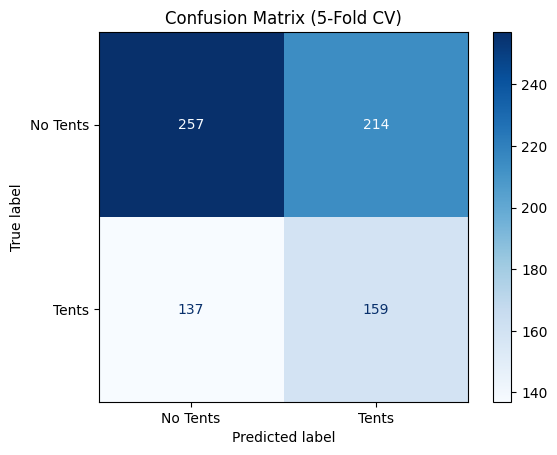

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


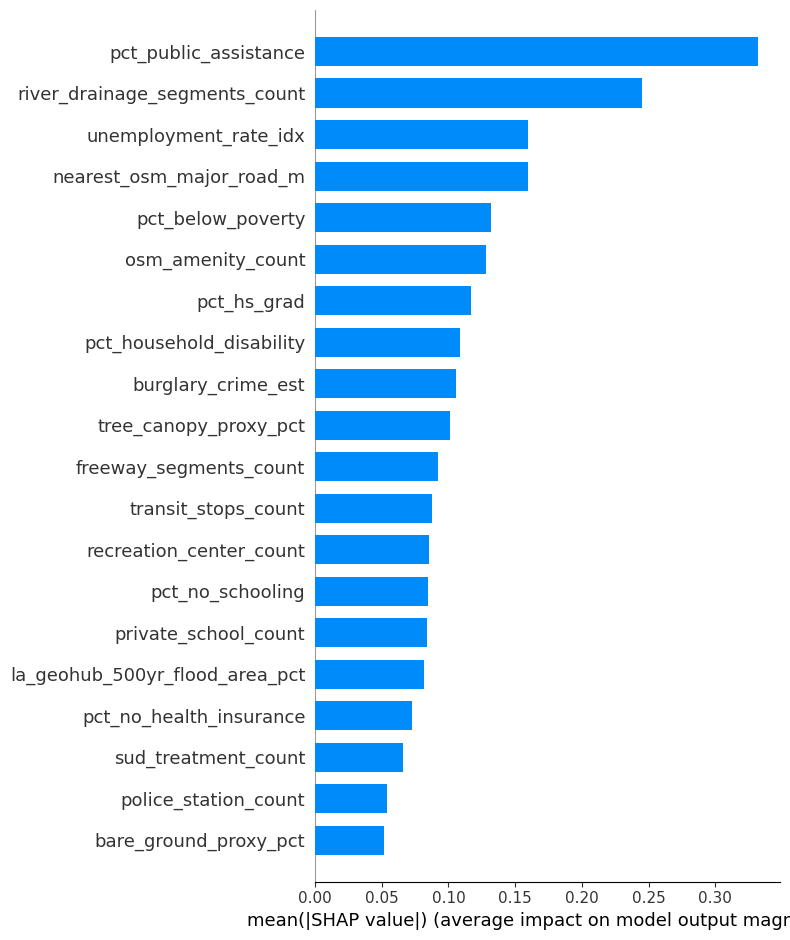

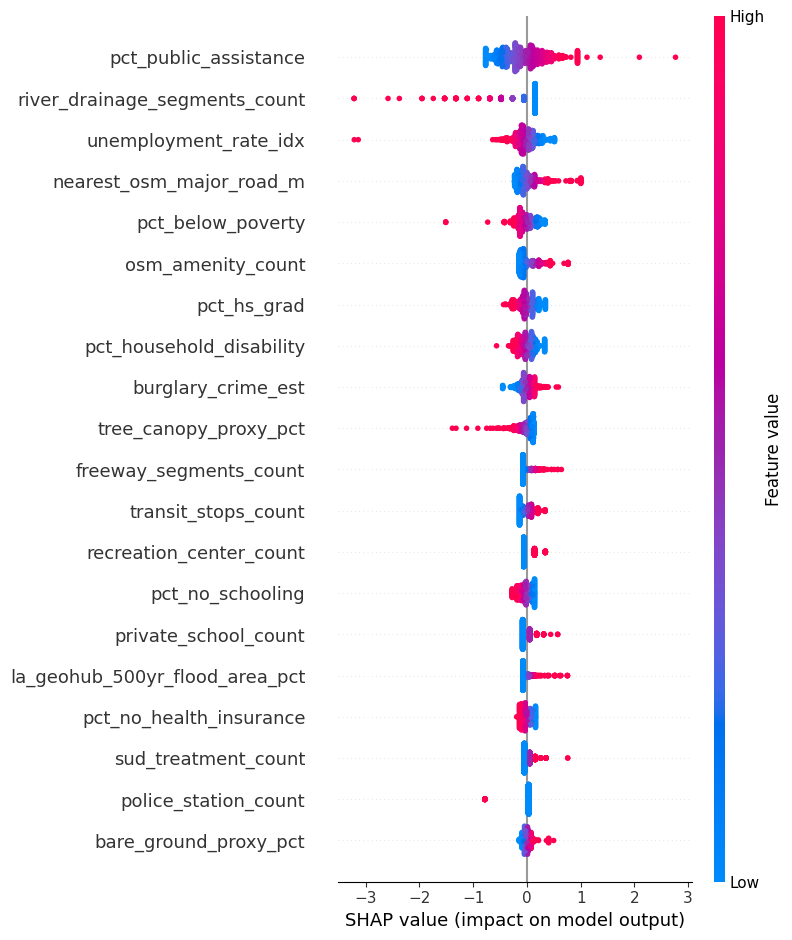

In [ ]:
# Standardize
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_final),
    columns=X_final.columns,
    index=X_final.index
)

# Model + CV
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# CV predictions
y_pred  = cross_val_predict(model, X_scaled, y_binary, cv=cv, method='predict')
y_proba = cross_val_predict(model, X_scaled, y_binary, cv=cv, method='predict_proba')[:, 1]

# Metrics
print(classification_report(y_binary, y_pred, target_names=['No Tents', 'Tents']))
print(f"AUC-ROC: {roc_auc_score(y_binary, y_proba):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_binary, y_pred,
    display_labels=['No Tents', 'Tents'],
    cmap='Blues'
)
plt.title("Confusion Matrix (5-Fold CV)")
plt.show()

# SHAP — fit on full data
model.fit(X_scaled, y_binary)
explainer   = shap.LinearExplainer(model, X_scaled, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_scaled)

shap.summary_plot(shap_values, X_scaled, plot_type="bar", max_display=20)
shap.summary_plot(shap_values, X_scaled, max_display=20)

In [ ]:
fpr, tpr, thresholds = roc_curve(y_binary, y_proba)
optimal_thresh = thresholds[np.argmax(tpr - fpr)]
y_pred_tuned   = (y_proba >= optimal_thresh).astype(int)

print(f"Optimal threshold: {optimal_thresh:.3f}")
print(classification_report(y_binary, y_pred_tuned, target_names=['No Tents', 'Tents']))

Optimal threshold: 0.393
              precision    recall  f1-score   support

    No Tents       0.73      0.36      0.48       471
       Tents       0.44      0.79      0.56       296

    accuracy                           0.52       767
   macro avg       0.58      0.57      0.52       767
weighted avg       0.62      0.52      0.51       767



In [ ]:
df_75.shape

(2150, 100)

In [ ]:
"""
RF Teacher → SNN Student Pipeline (v2)
========================================
Implements both:
  - SNN-1: 1-layer Superposable Neural Network (additive, one subnet per feature)
  - SNN-2: 2-layer SNN with pairwise interaction subnets on top of SNN-1

Distilled from a Random Forest teacher via 5-fold CV soft labels.

Architecture overview:
  SNN-1:  P(y=1) = σ( Σ_j  S_j(x_j) )
  SNN-2:  P(y=1) = σ( Σ_j  S_j(x_j)  +  Σ_{j<k} I_{jk}(x_j, x_k) )
"""

import argparse, json, os, warnings, itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

# ── Feature configuration ─────────────────────────────────────────────────────
FEATURES = [
    # Socioeconomic
    "burglary_crime_est",
    "total_crime_est",
    "total_population",
    "unemployment_rate_idx",
    "pct_veterans",
    "esri_market_idx_14068_forecast",
    "pct_hs_grad",
    "pct_no_health_insurance",
    "pct_no_schooling",
    "pct_severe_rent_burden",
    "pct_below_poverty",
    "pct_public_assistance",
    "pct_household_disability",
    # Facilities / Services
    "transit_stops_count",
    "hospital_count",
    "fire_station_count",
    "library_count",
    "college_count",
    "public_school_count",
    "private_school_count",
    "recreation_center_count",
    "adult_recreation_count",
    "affordable_housing_count",
    "sud_treatment_count",
    "business_sites_count",
    "police_station_count",
    "food_access_count",
    # Roads / Waterways
    "nearest_osm_major_road_m",
    "freeway_segments_count",
    "nearest_freeway_m",
    "river_drainage_segments_count",
    "osm_amenity_count",
    # Flood / Hazard
    "fema_flood_hazard_area_pct",
    "la_geohub_100yr_flood_area_pct",
    "la_geohub_100yr_flood_intersects",
    "la_geohub_500yr_flood_area_pct",
    "la_geohub_500yr_flood_intersects",
    "la_geohub_fire_hazard_area_pct",
    # Land Cover
    "tree_canopy_proxy_pct",
    "water_proxy_pct",
    "bare_ground_proxy_pct",
    "dominant_landcover_class",
]

FEATURE_LABELS = {
    "burglary_crime_est":             "Burglary Crime Est",
    "total_crime_est":                "Total Crime Est",
    "total_population":               "Total Population",
    "unemployment_rate_idx":          "Unemployment Rate Idx",
    "pct_veterans":                   "Pct Veterans",
    "esri_market_idx_14068_forecast": "Market Idx 14068 Forecast",
    "pct_hs_grad":                    "Pct HS Grad",
    "pct_no_health_insurance":        "Pct No Health Insurance",
    "pct_no_schooling":               "Pct No Schooling",
    "pct_severe_rent_burden":         "Pct Severe Rent Burden",
    "pct_below_poverty":              "Pct Below Poverty",
    "pct_public_assistance":          "Pct Public Assistance",
    "pct_household_disability":       "Pct HH Disability",
    "transit_stops_count":            "Transit Stops",
    "hospital_count":                 "Hospitals",
    "fire_station_count":             "Fire Stations",
    "library_count":                  "Libraries",
    "college_count":                  "Colleges",
    "public_school_count":            "Public Schools",
    "private_school_count":           "Private Schools",
    "recreation_center_count":        "Recreation Centers",
    "adult_recreation_count":         "Adult Recreation",
    "affordable_housing_count":       "Affordable Housing",
    "sud_treatment_count":            "SUD Treatment Sites",
    "business_sites_count":           "Business Sites",
    "police_station_count":           "Police Stations",
    "food_access_count":              "Food Access Sites",
    "nearest_osm_major_road_m":       "Nearest Major Road (m)",
    "freeway_segments_count":         "Freeway Segments",
    "nearest_freeway_m":              "Nearest Freeway (m)",
    "river_drainage_segments_count":  "River Drainage Segments",
    "osm_amenity_count":              "OSM Amenities",
    "fema_flood_hazard_area_pct":     "FEMA Flood Hazard Pct",
    "la_geohub_100yr_flood_area_pct": "100yr Flood Area Pct",
    "la_geohub_100yr_flood_intersects":"100yr Flood Intersects",
    "la_geohub_500yr_flood_area_pct": "500yr Flood Area Pct",
    "la_geohub_500yr_flood_intersects":"500yr Flood Intersects",
    "la_geohub_fire_hazard_area_pct": "Fire Hazard Area Pct",
    "tree_canopy_proxy_pct":          "Tree Canopy Pct",
    "water_proxy_pct":                "Water Pct",
    "bare_ground_proxy_pct":          "Bare Ground Pct",
    "dominant_landcover_class":       "Dominant Landcover Class",
}

TARGET_COL = "Join_Count"
ID_COL     = "OBJECTID"


# =============================================================================
# ARCHITECTURES
# =============================================================================

class SubNet1(nn.Module):
    def __init__(self, n_rbf: int = 10):
        super().__init__()
        self.centers    = nn.Parameter(torch.linspace(-2.5, 2.5, n_rbf))
        self.log_widths = nn.Parameter(torch.zeros(n_rbf))
        self.linear     = nn.Linear(n_rbf, 1, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x   = x.unsqueeze(1)
        c   = self.centers.unsqueeze(0)
        w   = torch.exp(self.log_widths).unsqueeze(0)
        rbf = torch.exp(-w * (x - c) ** 2)
        return self.linear(rbf).squeeze(1)

    def get_curve(self, x_range=(-3, 3), n_pts=200):
        xs = torch.linspace(*x_range, n_pts)
        with torch.no_grad():
            ys = self.forward(xs).numpy()
        return xs.numpy(), ys


class SubNet2(nn.Module):
    def __init__(self, n_rbf: int = 6):
        super().__init__()
        pts = torch.linspace(-2.5, 2.5, n_rbf)
        cj, ck = torch.meshgrid(pts, pts, indexing="ij")
        self.register_buffer("cj", cj.reshape(-1))
        self.register_buffer("ck", ck.reshape(-1))
        n_basis = n_rbf * n_rbf
        self.log_wj = nn.Parameter(torch.zeros(n_basis))
        self.log_wk = nn.Parameter(torch.zeros(n_basis))
        self.linear = nn.Linear(n_basis, 1, bias=True)

    def forward(self, xj: torch.Tensor, xk: torch.Tensor) -> torch.Tensor:
        wj  = torch.exp(self.log_wj)
        wk  = torch.exp(self.log_wk)
        phi = torch.exp(-wj * (xj.unsqueeze(1) - self.cj) ** 2) * \
              torch.exp(-wk * (xk.unsqueeze(1) - self.ck) ** 2)
        return self.linear(phi).squeeze(1)


# =============================================================================
# TRAINING: SNN-1
# =============================================================================

def train_snn1(X_np, soft_targets, hard_labels, n_rbf=10, n_rounds=4,
               epochs=500, lr=2e-3, verbose=True):
    n, n_feat = X_np.shape
    X_t = torch.tensor(X_np,         dtype=torch.float32)
    ts0 = torch.tensor(soft_targets, dtype=torch.float32)
    nets = [SubNet1(n_rbf) for _ in range(n_feat)]
    fo   = [torch.zeros(n) for _ in range(n_feat)]

    if verbose: print(f"  [SNN-1] Round 1/{n_rounds}: sequential distillation")
    residual = ts0.clone()
    for j, net in enumerate(nets):
        opt = torch.optim.Adam(net.parameters(), lr=lr)
        for _ in range(epochs):
            opt.zero_grad()
            nn.MSELoss()(net(X_t[:, j]), residual).backward()
            opt.step()
        with torch.no_grad():
            fo[j]    = net(X_t[:, j])
            residual = residual - fo[j]

    for rnd in range(1, n_rounds):
        lr_r = lr * (0.6 ** rnd)
        for j, net in enumerate(nets):
            others   = sum(fo[k].detach() for k in range(n_feat) if k != j)
            target_j = ts0 - others
            opt = torch.optim.Adam(net.parameters(), lr=lr_r)
            for _ in range(epochs):
                opt.zero_grad()
                nn.MSELoss()(net(X_t[:, j]), target_j).backward()
                opt.step()
            with torch.no_grad():
                fo[j] = net(X_t[:, j])
        if verbose:
            auc = roc_auc_score(
                hard_labels,
                torch.sigmoid(torch.stack(fo, 1).sum(1)).numpy()
            )
            print(f"  [SNN-1] Round {rnd+1}/{n_rounds}: AUC={auc:.4f}  lr={lr_r:.5f}")

    contribs = torch.stack(fo, 1).detach().numpy()
    probs    = torch.sigmoid(torch.tensor(contribs.sum(1), dtype=torch.float32)).numpy()
    return nets, contribs, probs


# =============================================================================
# TRAINING: SNN-2
# =============================================================================

def select_top_pairs(X_np, hard_labels, n_feat, top_k=20):
    print(f"  [SNN-2] Selecting top {top_k} pairs via RF interaction screen...")
    pairs    = list(itertools.combinations(range(n_feat), 2))
    products = np.column_stack([X_np[:, j] * X_np[:, k] for j, k in pairs])
    rf_screen = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)
    rf_screen.fit(products, hard_labels)
    ranked    = sorted(zip(pairs, rf_screen.feature_importances_), key=lambda x: -x[1])
    top_pairs = [p for p, _ in ranked[:top_k]]
    print(f"  [SNN-2] Top pair: {FEATURES[top_pairs[0][0]]} x {FEATURES[top_pairs[0][1]]}")
    return top_pairs


def train_snn2(X_np, soft_targets, hard_labels, snn1_contribs,
               top_pairs, n_rbf2=6, n_rounds=3, epochs=400, lr=1e-3, verbose=True):
    n    = X_np.shape[0]
    X_t  = torch.tensor(X_np,                dtype=torch.float32)
    ts0  = torch.tensor(soft_targets,         dtype=torch.float32)
    base = torch.tensor(snn1_contribs.sum(1), dtype=torch.float32)
    pair_nets = {jk: SubNet2(n_rbf2) for jk in top_pairs}
    pair_fo   = {jk: torch.zeros(n)  for jk in top_pairs}

    if verbose: print(f"  [SNN-2] Round 1/{n_rounds}: sequential interaction distillation")
    residual = ts0 - base
    for jk in top_pairs:
        j, k = jk
        net  = pair_nets[jk]
        opt  = torch.optim.Adam(net.parameters(), lr=lr)
        for _ in range(epochs):
            opt.zero_grad()
            nn.MSELoss()(net(X_t[:, j], X_t[:, k]), residual).backward()
            opt.step()
        with torch.no_grad():
            pair_fo[jk] = net(X_t[:, j], X_t[:, k])
            residual     = residual - pair_fo[jk]

    for rnd in range(1, n_rounds):
        lr_r = lr * (0.5 ** rnd)
        for jk in top_pairs:
            j, k   = jk
            others = sum(pair_fo[p].detach() for p in top_pairs if p != jk)
            target = ts0 - base - others
            opt    = torch.optim.Adam(pair_nets[jk].parameters(), lr=lr_r)
            for _ in range(epochs):
                opt.zero_grad()
                nn.MSELoss()(pair_nets[jk](X_t[:, j], X_t[:, k]), target).backward()
                opt.step()
            with torch.no_grad():
                pair_fo[jk] = pair_nets[jk](X_t[:, j], X_t[:, k])
        if verbose:
            total = base + sum(pair_fo[p].detach() for p in top_pairs)
            auc   = roc_auc_score(hard_labels, torch.sigmoid(total).numpy())
            print(f"  [SNN-2] Round {rnd+1}/{n_rounds}: AUC={auc:.4f}  lr={lr_r:.5f}")

    pair_contribs = np.column_stack([pair_fo[jk].detach().numpy() for jk in top_pairs])
    probs         = 1 / (1 + np.exp(-(base.numpy() + pair_contribs.sum(1))))
    return pair_nets, pair_contribs, probs


# =============================================================================
# HELPERS
# =============================================================================

def optimal_threshold(y, probs):
    fpr, tpr, thresholds = roc_curve(y, probs)
    return float(thresholds[np.argmax(tpr - fpr)])


def build_feature_summary(features, contribs, y, rf):
    delta    = contribs[y == 1].mean(0) - contribs[y == 0].mean(0)
    mean_abs = np.abs(contribs).mean(0)
    return pd.DataFrame({
        "feature":       features,
        "label":         [FEATURE_LABELS.get(f, f) for f in features],
        "rf_importance": rf.feature_importances_,
        "mean_abs_sj":   mean_abs,
        "delta_sj":      delta,
    }).sort_values("delta_sj", ascending=False).reset_index(drop=True)


def build_interaction_summary(top_pairs, pair_contribs, y, features):
    rows = []
    for idx, (j, k) in enumerate(top_pairs):
        col = pair_contribs[:, idx]
        rows.append({
            "feature_j":    features[j],
            "feature_k":    features[k],
            "label_j":      FEATURE_LABELS.get(features[j], features[j]),
            "label_k":      FEATURE_LABELS.get(features[k], features[k]),
            "mean_abs_Ijk": np.abs(col).mean(),
            "delta_Ijk":    col[y == 1].mean() - col[y == 0].mean(),
        })
    return pd.DataFrame(rows).sort_values("delta_Ijk", ascending=False).reset_index(drop=True)


def build_hex_output_snn1(ids, y, probs, contribs, features, thresh):
    contrib_df = pd.DataFrame(contribs, columns=[f"Sj_{f}" for f in features])
    return pd.concat([
        pd.Series(ids.values,                    name="hex_id"),
        pd.Series(y,                             name="tent_present"),
        pd.Series(probs,                         name="snn1_prob"),
        pd.Series((probs >= thresh).astype(int), name="snn1_pred"),
        contrib_df,
    ], axis=1)


def build_hex_output_snn2(ids, y, probs, snn1_contribs, pair_contribs,
                           features, top_pairs, thresh):
    snn1_df = pd.DataFrame(snn1_contribs, columns=[f"Sj_{f}" for f in features])
    pair_df = pd.DataFrame(
        {f"Ijk_{features[j]}_{features[k]}": pair_contribs[:, idx]
         for idx, (j, k) in enumerate(top_pairs)}
    )
    return pd.concat([
        pd.Series(ids.values,                    name="hex_id"),
        pd.Series(y,                             name="tent_present"),
        pd.Series(probs,                         name="snn2_prob"),
        pd.Series((probs >= thresh).astype(int), name="snn2_pred"),
        snn1_df, pair_df,
    ], axis=1)


def extract_curves_snn1(nets, features, X_raw):
    curves = {}
    for j, (f, net) in enumerate(zip(features, nets)):
        xs, ys = net.get_curve(x_range=(-3.0, 3.0), n_pts=200)
        x_raw  = np.linspace(float(X_raw[f].min()), float(X_raw[f].max()), 200)
        curves[f] = {
            "label": FEATURE_LABELS.get(f, f),
            "x_std": xs.tolist(),
            "x_raw": x_raw.tolist(),
            "y":     ys.tolist(),
        }
    return curves


def print_results(label, rf_auc, model_auc, model_ap, thresh, report):
    print("\n" + "=" * 60)
    print(f"RESULTS - {label}")
    print("=" * 60)
    print(f"  RF teacher AUC (CV):  {rf_auc:.4f}")
    print(f"  {label} AUC:          {model_auc:.4f}")
    print(f"  {label} AP:           {model_ap:.4f}")
    print(f"  Optimal threshold:    {thresh:.3f}")
    print()
    print(report)


def print_feature_table(summary):
    print("-- Feature contributions (dSj = tent - no-tent) ----------")
    print(f"{'#':<3} {'Feature':<32} {'dSj':>8}  direction")
    print("-" * 58)
    for i, row in summary.iterrows():
        bar = ("^" if row["delta_sj"] > 0 else "v") * min(int(abs(row["delta_sj"]) / 0.005), 20)
        print(f"{i+1:<3} {row['label']:<32} {row['delta_sj']:>+8.4f}  {bar}")


def print_interaction_table(inter_summary, top_n=15):
    print(f"\n-- Top interaction contributions (dI_jk) ----------------")
    print(f"{'#':<3} {'Pair':<48} {'dIjk':>8}")
    print("-" * 62)
    for i, row in inter_summary.head(top_n).iterrows():
        pair = f"{row['label_j']} x {row['label_k']}"
        print(f"{i+1:<3} {pair:<48} {row['delta_Ijk']:>+8.4f}")


# =============================================================================
# MAIN
# =============================================================================

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data",      default="/content/half_variables_and_tents_geo_enriched.csv")
    parser.add_argument("--out",       default="outputs")
    parser.add_argument("--rbf",       type=int,   default=10)
    parser.add_argument("--rbf2",      type=int,   default=6)
    parser.add_argument("--rounds",    type=int,   default=4)
    parser.add_argument("--rounds2",   type=int,   default=3)
    parser.add_argument("--epochs",    type=int,   default=500)
    parser.add_argument("--epochs2",   type=int,   default=400)
    parser.add_argument("--lr",        type=float, default=2e-3)
    parser.add_argument("--lr2",       type=float, default=1e-3)
    parser.add_argument("--top_pairs", type=int,   default=20)
    args, _ = parser.parse_known_args()

    os.makedirs(args.out, exist_ok=True)

    # ── Load ──────────────────────────────────────────────────────────────────
    try:
        X   = X_final[FEATURES].fillna(0).reset_index(drop=True)
        y   = y_binary.values if hasattr(y_binary, "values") else np.array(y_binary)
        ids = pd.Series(range(len(X)))
        print(f"\nUsing in-memory X_final / y_binary ({len(X)} hexes)")
    except NameError:
        print(f"\nLoading: {args.data}")
        df  = pd.read_csv(args.data)
        X   = df[FEATURES].fillna(0)
        y   = (df[TARGET_COL] > 0).astype(int).values
        ids = df[ID_COL] if ID_COL in df.columns else pd.Series(range(len(df)))

    print(f"  {len(X)} hexes | {len(FEATURES)} features | "
          f"{y.sum()} tent-present ({y.mean()*100:.1f}%)")

    # ── Scale ─────────────────────────────────────────────────────────────────
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── RF Teacher ────────────────────────────────────────────────────────────
    print("\nStep 1: RF teacher (5-fold CV soft labels)...")
    rf = RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        max_depth=8, random_state=42, n_jobs=-1,
    )
    cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    soft_labels = cross_val_predict(rf, X_scaled, y, cv=cv, method="predict_proba")[:, 1]
    rf.fit(X_scaled, y)
    rf_auc = roc_auc_score(y, soft_labels)
    print(f"  RF AUC (CV): {rf_auc:.4f}")

    # =========================================================================
    # SNN-1
    # =========================================================================
    print(f"\nStep 2: SNN-1 distillation "
          f"(rbf={args.rbf}, rounds={args.rounds}, epochs={args.epochs})...")
    nets1, contribs1, probs1 = train_snn1(
        X_scaled, soft_labels, y,
        n_rbf=args.rbf, n_rounds=args.rounds,
        epochs=args.epochs, lr=args.lr, verbose=True,
    )

    thresh1  = optimal_threshold(y, probs1)
    auc1     = roc_auc_score(y, probs1)
    ap1      = average_precision_score(y, probs1)
    preds1   = (probs1 >= thresh1).astype(int)
    report1  = classification_report(y, preds1, target_names=["no tent", "tent"])
    summary1 = build_feature_summary(FEATURES, contribs1, y, rf)

    print_results("SNN-1", rf_auc, auc1, ap1, thresh1, report1)
    print_feature_table(summary1)

    hex1    = build_hex_output_snn1(ids, y, probs1, contribs1, FEATURES, thresh1)
    curves1 = extract_curves_snn1(nets1, FEATURES, X)

    summary1.to_csv(f"{args.out}/snn1_feature_summary.csv",   index=False)
    hex1.to_csv(    f"{args.out}/snn1_hex_contributions.csv", index=False)
    with open(f"{args.out}/snn1_curves.json", "w") as fh:
        json.dump(curves1, fh)
    with open(f"{args.out}/snn1_metrics.txt", "w") as fh:
        fh.write(f"RF teacher AUC (CV): {rf_auc:.4f}\n")
        fh.write(f"SNN-1 AUC:           {auc1:.4f}\n")
        fh.write(f"SNN-1 AP:            {ap1:.4f}\n")
        fh.write(f"Optimal threshold:   {thresh1:.3f}\n\n")
        fh.write(report1)
    torch.save({
        "nets":         [n.state_dict() for n in nets1],
        "scaler_mean":  scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
        "features":     FEATURES,
        "threshold":    thresh1,
        "n_rbf":        args.rbf,
    }, f"{args.out}/snn_model1.pt")

    # =========================================================================
    # SNN-2
    # =========================================================================
    print(f"\nStep 3: SNN-2 - selecting top {args.top_pairs} pairwise interactions...")
    top_pairs = select_top_pairs(X_scaled, y, len(FEATURES), top_k=args.top_pairs)

    print(f"\nStep 4: SNN-2 interaction distillation "
          f"(rbf2={args.rbf2}, rounds={args.rounds2}, epochs={args.epochs2})...")
    pair_nets, pair_contribs, probs2 = train_snn2(
        X_scaled, soft_labels, y, contribs1,
        top_pairs, n_rbf2=args.rbf2, n_rounds=args.rounds2,
        epochs=args.epochs2, lr=args.lr2, verbose=True,
    )

    thresh2   = optimal_threshold(y, probs2)
    auc2      = roc_auc_score(y, probs2)
    ap2       = average_precision_score(y, probs2)
    preds2    = (probs2 >= thresh2).astype(int)
    report2   = classification_report(y, preds2, target_names=["no tent", "tent"])
    summary2  = build_feature_summary(FEATURES, contribs1, y, rf)
    inter_sum = build_interaction_summary(top_pairs, pair_contribs, y, FEATURES)

    print_results("SNN-2", rf_auc, auc2, ap2, thresh2, report2)
    print_feature_table(summary2)
    print_interaction_table(inter_sum)
    print(f"\n  AUC lift SNN-1 -> SNN-2: {auc1:.4f} -> {auc2:.4f} "
          f"({(auc2-auc1)*100:+.2f} pp)")

    hex2 = build_hex_output_snn2(
        ids, y, probs2, contribs1, pair_contribs, FEATURES, top_pairs, thresh2
    )
    summary2.to_csv(  f"{args.out}/snn2_feature_summary.csv",    index=False)
    inter_sum.to_csv( f"{args.out}/snn2_interaction_summary.csv", index=False)
    hex2.to_csv(      f"{args.out}/snn2_hex_contributions.csv",   index=False)
    with open(f"{args.out}/snn2_metrics.txt", "w") as fh:
        fh.write(f"RF teacher AUC (CV): {rf_auc:.4f}\n")
        fh.write(f"SNN-1 AUC:           {auc1:.4f}\n")
        fh.write(f"SNN-2 AUC:           {auc2:.4f}\n")
        fh.write(f"SNN-2 AP:            {ap2:.4f}\n")
        fh.write(f"Optimal threshold:   {thresh2:.3f}\n\n")
        fh.write(report2)
    torch.save({
        "snn1_nets":    [n.state_dict() for n in nets1],
        "pair_nets":    {str(k): v.state_dict() for k, v in pair_nets.items()},
        "top_pairs":    top_pairs,
        "scaler_mean":  scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
        "features":     FEATURES,
        "threshold":    thresh2,
        "n_rbf":        args.rbf,
        "n_rbf2":       args.rbf2,
    }, f"{args.out}/snn_model2.pt")

    print("\n" + "=" * 60)
    print("ALL OUTPUTS")
    print("=" * 60)
    for fname in [
        "snn1_feature_summary.csv", "snn1_hex_contributions.csv",
        "snn1_curves.json", "snn1_metrics.txt", "snn_model1.pt",
        "snn2_feature_summary.csv", "snn2_interaction_summary.csv",
        "snn2_hex_contributions.csv", "snn2_metrics.txt", "snn_model2.pt",
    ]:
        print(f"  -> {args.out}/{fname}")


if __name__ == "__main__":
    main()


Using in-memory X_final / y_binary (767 hexes)
  767 hexes | 42 features | 296 tent-present (38.6%)

Step 1: RF teacher (5-fold CV soft labels)...
  RF AUC (CV): 0.6054

Step 2: SNN-1 distillation (rbf=10, rounds=4, epochs=500)...
  [SNN-1] Round 1/4: sequential distillation
  [SNN-1] Round 2/4: AUC=0.7054  lr=0.00120
  [SNN-1] Round 3/4: AUC=0.7090  lr=0.00072
  [SNN-1] Round 4/4: AUC=0.7115  lr=0.00043

RESULTS - SNN-1
  RF teacher AUC (CV):  0.6054
  SNN-1 AUC:          0.7115
  SNN-1 AP:           0.6108
  Optimal threshold:    0.609

              precision    recall  f1-score   support

     no tent       0.76      0.65      0.70       471
        tent       0.55      0.68      0.61       296

    accuracy                           0.66       767
   macro avg       0.65      0.66      0.65       767
weighted avg       0.68      0.66      0.66       767

-- Feature contributions (dSj = tent - no-tent) ----------
#   Feature                               dSj  direction
-----------

In [ ]:
print(X_final.columns.tolist())


['burglary_crime_est', 'total_crime_est', 'total_population', 'unemployment_rate_idx', 'pct_veterans', 'esri_market_idx_14068_forecast', 'pct_hs_grad', 'pct_no_health_insurance', 'pct_no_schooling', 'pct_severe_rent_burden', 'pct_below_poverty', 'pct_public_assistance', 'pct_household_disability', 'transit_stops_count', 'hospital_count', 'fire_station_count', 'library_count', 'college_count', 'public_school_count', 'private_school_count', 'recreation_center_count', 'adult_recreation_count', 'affordable_housing_count', 'sud_treatment_count', 'business_sites_count', 'police_station_count', 'food_access_count', 'nearest_osm_major_road_m', 'freeway_segments_count', 'nearest_freeway_m', 'river_drainage_segments_count', 'osm_amenity_count', 'fema_flood_hazard_area_pct', 'la_geohub_100yr_flood_area_pct', 'la_geohub_100yr_flood_intersects', 'la_geohub_500yr_flood_area_pct', 'la_geohub_500yr_flood_intersects', 'la_geohub_fire_hazard_area_pct', 'tree_canopy_proxy_pct', 'water_proxy_pct', 'bare_g

In [ ]:
df_75 = pd.read_csv('/content/three_fourth_variables_and_tent_geo_enriched.csv')

In [ ]:
df_75_test = pd.read_csv('/content/outputLayer_0 10.csv')

In [ ]:
df_75.shape

(2150, 100)

In [ ]:
df_75 = pd.merge(df_75_test,df_75,on = 'OBJECTID',how='inner' )

In [ ]:
df_75

,OBJECTID,Join_Count_x,TARGET_FID_x,GRID_ID_x,Join_Count_y,TARGET_FID_y,JOIN_FID,GRID_ID_y,ID,sourceCountry,...,la_geohub_fire_hazard_intersects,heat_exposure_area_pct,heat_exposure_intersects,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,dominant_landcover_class,heat_exposure_proxy_score
0,1,0,1,Y-47,0,1,-1,I-10,0,US,...,1,0.0,0,2.70,20.34,52.62,6.47,20.58,5.0,66.02
1,2,0,2,Z-47,0,2,-1,J-10,1,US,...,1,0.0,0,3.41,17.48,62.44,4.05,16.03,5.0,72.68
2,3,0,3,X-46,0,3,-1,K-10,2,US,...,1,0.0,0,0.47,12.06,72.47,2.41,13.06,5.0,80.59
3,4,0,4,Y-46,1,4,1186,L-10,3,US,...,1,0.0,0,1.04,8.80,75.93,3.24,12.04,5.0,82.84
4,5,1,5,Z-46,1,4,1724,L-10,3,US,...,1,0.0,0,1.04,8.80,75.93,3.24,12.04,5.0,82.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,535,0,535,K-1,0,277,-1,O-11,24,US,...,1,0.0,0,3.76,21.11,55.12,5.49,18.28,5.0,67.46
535,536,0,536,L-1,0,278,-1,S-5,12,US,...,1,0.0,0,7.52,45.83,20.39,3.64,30.14,4.0,42.02
536,537,0,537,M-1,1,279,215,P-11,25,US,...,1,0.0,0,1.06,10.41,73.25,4.35,11.99,5.0,80.96
537,538,0,538,N-1,1,279,401,P-11,25,US,...,1,0.0,0,1.06,10.41,73.25,4.35,11.99,5.0,80.96


In [ ]:
df_75['tent_prediction_count'].value_counts()

,count
tent_prediction_count,
1.0,1546
2.0,264
3.0,62
4.0,23
5.0,9
6.0,1
7.0,1


In [ ]:
df_75['tent_prediction_count'].unique()

array([nan,  1.,  2.,  3.,  4.,  5.,  6.,  7.])

In [ ]:
## Taking required features
df_75_feature = df_75.drop(['OBJECTID','TARGET_FID_x','Join_Count_y','TARGET_FID_y','JOIN_FID','GRID_ID_x','GRID_ID_y','ID','sourceCountry','ENRICH_FID','aggregationMethod','populationToPolygonSizeRating','apportionmentConfidence','HasData','ID_1','sourceCountry_1','ENRICH_FID_1','populationToPolygonSizeRating_1','aggregationMethod_1','populationToPolygonSizeRating_1','HasData_1','source_run','latitude','longitude','address','heading','filename','tent_prediction_count','max_conf','classes_seen','tent_ref_max_conf','tent_ref_mean_conf'],axis=1)

In [ ]:
zero_variance_columns = df_75_feature.columns[df_75_feature.var() == 0]
all_zeros_columns = df_75_feature.columns[(df_75_feature == 0).all()]

print("Columns with zero variance:")
print(zero_variance_columns.tolist())

print("\nColumns with all zeros:")
print(all_zeros_columns.tolist())

Columns with zero variance:
['tent_ref_point_count', 'tent_ref_prediction_sum', 'cool_zone_count', 'la_geohub_fire_hazard_intersects', 'heat_exposure_area_pct', 'heat_exposure_intersects']

Columns with all zeros:
['tent_ref_point_count', 'tent_ref_prediction_sum', 'cool_zone_count', 'heat_exposure_area_pct', 'heat_exposure_intersects']


In [ ]:
zero_variance_columns = df_75_feature.columns[df_75_feature.var() == 0]
all_zeros_columns = df_75_feature.columns[(df_75_feature == 0).all()]

print("Columns with zero variance:")
print(zero_variance_columns.tolist())

print("\nColumns with all zeros:")
print(all_zeros_columns.tolist())

Columns with zero variance:
['tent_ref_point_count', 'tent_ref_prediction_sum', 'cool_zone_count', 'la_geohub_fire_hazard_intersects', 'heat_exposure_area_pct', 'heat_exposure_intersects']

Columns with all zeros:
['tent_ref_point_count', 'tent_ref_prediction_sum', 'cool_zone_count', 'heat_exposure_area_pct', 'heat_exposure_intersects']


In [ ]:
# Drop columns with very low variance
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_final)
low_var_cols = X_final.columns[~selector.get_support()].tolist()
print("Low variance cols to drop:", low_var_cols)

Low variance cols to drop: []


In [ ]:
## drop columns with zero variance
columns_to_drop = list(set(zero_variance_columns.tolist() + all_zeros_columns.tolist()))
df_75_feature = df_75_feature.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
display(df_75_feature.head())

Dropped columns: ['tent_ref_prediction_sum', 'heat_exposure_area_pct', 'heat_exposure_intersects', 'la_geohub_fire_hazard_intersects', 'cool_zone_count', 'tent_ref_point_count']


,Join_Count_x,CRMCYBURG,CRMCYTOTC,TOTPOP_CY,UNEMPRT_CY_I,HISPPOP_CY_P,MEDHINC_CY_I,ACSVET_P,apportionmentConfidence_1,ACSHHDIS_P,...,la_geohub_500yr_flood_area_pct,la_geohub_500yr_flood_intersects,la_geohub_fire_hazard_area_pct,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,dominant_landcover_class,heat_exposure_proxy_score
0,0,89,85,8099,45,49.92,118,2.89,2.576,23.57,...,0.0,0,100.0,2.70,20.34,52.62,6.47,20.58,5.0,66.02
1,0,91,81,4856,183,50.10,127,4.93,2.576,27.55,...,0.0,0,100.0,3.41,17.48,62.44,4.05,16.03,5.0,72.68
2,0,118,140,3794,181,59.44,90,3.31,2.576,26.49,...,0.0,0,100.0,0.47,12.06,72.47,2.41,13.06,5.0,80.59
3,0,116,158,3377,148,68.02,97,3.51,2.576,15.89,...,0.0,0,100.0,1.04,8.80,75.93,3.24,12.04,5.0,82.84
4,1,116,158,3377,148,68.02,97,3.51,2.576,15.89,...,0.0,0,100.0,1.04,8.80,75.93,3.24,12.04,5.0,82.84


In [ ]:
# Diagnose first
print("NaN counts:")
print(df_75_feature.isnull().sum()[df_75_feature.isnull().sum() > 0])

print("\nInf counts:")
inf_mask = np.isinf(df_75_feature.select_dtypes(include=np.number))
print(inf_mask.sum()[inf_mask.sum() > 0])

# Replace inf with NaN then fill
df_75_feature = df_75_feature.replace([np.inf, -np.inf], np.nan)
df_75_feature = df_75_feature.fillna(df_75_feature.median())

# Now rerun VIF
X = add_constant(df_75_feature)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

NaN counts:
Series([], dtype: int64)

Inf counts:
Series([], dtype: int64)
                      feature           VIF
61       impervious_proxy_pct  3.411444e+07
65  heat_exposure_proxy_score  2.602002e+07
60       vegetation_proxy_pct  7.354510e+06
63      bare_ground_proxy_pct  1.016475e+06
62            water_proxy_pct  6.209853e+05
..                        ...           ...
19              hex_area_sqkm  4.701662e-07
22        climate_ppt_2024_mm  4.761825e-08
21        climate_tmax_2024_c  4.230348e-08
20         climate_t2m_2024_c  0.000000e+00
8   apportionmentConfidence_1  0.000000e+00

[66 rows x 2 columns]


In [ ]:
# 1. Re-run the function definition
def iterative_vif_drop(df, threshold=10):
    cols = list(df.columns)
    dropped = []

    while True:
        vif_df = pd.DataFrame({
            "feature": cols,
            "VIF": [variance_inflation_factor(df[cols].values, i)
                    for i in range(len(cols))]
        }).sort_values("VIF", ascending=False)

        max_vif = vif_df.iloc[0]["VIF"]
        if max_vif <= threshold:
            break

        drop_col = vif_df.iloc[0]["feature"]
        print(f"Dropping {drop_col} (VIF={max_vif:.1f})")
        dropped.append({"feature": drop_col, "VIF_at_drop": max_vif})
        cols.remove(drop_col)

    return cols, vif_df, pd.DataFrame(dropped)

# 2. Then call it
y = df_75_feature['Join_Count_x']
X = df_75_feature.drop(columns=['Join_Count_x'])

surviving_cols, final_vif_df, drop_log = iterative_vif_drop(X, threshold=10)

X_clean = X[surviving_cols]
print(final_vif_df)
print(f"\nDropped {len(drop_log)} features:")
print(drop_log)


Dropping impervious_proxy_pct (VIF=34046364.8)
Dropping heat_exposure_proxy_score (VIF=8333014.9)
Dropping gas_station_count (VIF=567.1)
Dropping X14068_X_I (VIF=453.6)
Dropping freeway_length_m (VIF=97.7)
Dropping osm_major_road_length_m (VIF=15.8)
Dropping MEDHINC_CY_I (VIF=15.1)
Dropping ACSVET_P (VIF=10.4)
                             feature       VIF
43         caltrans_highway_length_m  9.328019
36            freeway_segments_count  8.373417
0                          CRMCYBURG  7.928664
4                       HISPPOP_CY_P  7.331830
53              vegetation_proxy_pct  6.998231
44        nearest_caltrans_highway_m  5.766881
39           river_drainage_length_m  5.671347
30              business_sites_count  5.657274
52             tree_canopy_proxy_pct  5.554623
34     osm_major_road_segments_count  5.325420
38     river_drainage_segments_count  5.038608
2                          TOTPOP_CY  4.992382
1                          CRMCYTOTC  4.883548
42   caltrans_highway_segments

In [ ]:
import numpy as np

def drop_high_corr(df, threshold=0.7):
    corr_matrix = df.corr().abs()
    dropped_corr = []

    cols = list(df.columns)

    while True:
        corr_matrix = df[cols].corr().abs()

        # Get upper triangle pairs above threshold
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr_pairs = [(col, row, upper.loc[row, col])
                          for col in upper.columns
                          for row in upper.index
                          if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > threshold]

        if not high_corr_pairs:
            break

        # Find all cols involved in high corr pairs
        flagged = set()
        for c1, c2, _ in high_corr_pairs:
            flagged.update([c1, c2])

        # Drop the one with highest avg correlation to all other variables
        avg_corr = corr_matrix[list(flagged)].mean(axis=0)
        drop_col = avg_corr.idxmax()

        print(f"Dropping {drop_col} (avg_corr={avg_corr[drop_col]:.3f})")
        dropped_corr.append({"feature": drop_col, "avg_corr_at_drop": avg_corr[drop_col]})
        cols.remove(drop_col)

    return cols, pd.DataFrame(dropped_corr)

# Run it
surviving_cols_corr, corr_drop_log = drop_high_corr(X_clean, threshold=0.7)

X_final = X_clean[surviving_cols_corr]
print(f"\n{len(X_clean.columns)} → {len(X_final.columns)} features after correlation pruning")
print(f"\nRemaining features:\n{surviving_cols_corr}")

Dropping transit_stops_count (avg_corr=0.256)
Dropping HISPPOP_CY_P (avg_corr=0.244)
Dropping vegetation_proxy_pct (avg_corr=0.225)
Dropping CRMCYBURG (avg_corr=0.197)
Dropping osm_major_road_segments_count (avg_corr=0.181)
Dropping river_drainage_length_m (avg_corr=0.165)
Dropping caltrans_highway_length_m (avg_corr=0.165)
Dropping nearest_caltrans_highway_m (avg_corr=0.150)
Dropping caltrans_highway_segments_count (avg_corr=0.139)

57 → 48 features after correlation pruning

Remaining features:
['CRMCYTOTC', 'TOTPOP_CY', 'UNEMPRT_CY_I', 'apportionmentConfidence_1', 'ACSHHDIS_P', 'ACSPUBAI_P', 'ACSGRNTI50_P', 'ACSEDNOSCH_P', 'ACS35NOHI_P', 'ACSVET_P_1', 'ACSHSGRAD_P', 'ACSHHPBLPV_P', 'X14068FY_X_I', 'hex_area_sqkm', 'climate_t2m_2024_c', 'climate_tmax_2024_c', 'climate_ppt_2024_mm', 'hospital_count', 'fire_station_count', 'library_count', 'college_count', 'public_school_count', 'private_school_count', 'recreation_center_count', 'adult_recreation_count', 'affordable_housing_count', 'su

In [ ]:
# Drop columns with very low variance
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_final)
low_var_cols = X_final.columns[~selector.get_support()].tolist()
print("Low variance cols to drop:", low_var_cols)

Low variance cols to drop: ['apportionmentConfidence_1', 'hex_area_sqkm', 'climate_t2m_2024_c', 'climate_tmax_2024_c', 'climate_ppt_2024_mm']


In [ ]:
X_final = X_final.drop(columns=low_var_cols)
print(f"Final feature count: {X_final.shape[1]}")

Final feature count: 43


In [ ]:
y_binary = (y > 0).astype(int)

print(y_binary.value_counts())
print(f"Class balance: {y_binary.mean():.2%} positive")

Join_Count_x
0    289
1    250
Name: count, dtype: int64
Class balance: 46.38% positive


In [ ]:
289+250

539

In [ ]:
rename_map = {
    'CRMCYBURG': 'burglary_crime_est',
    'CRMCYTOTC': 'total_crime_est',
    'TOTPOP_CY': 'total_population',
    'UNEMPRT_CY_I': 'unemployment_rate_idx',
    'HISPPOP_CY_P': 'pct_hispanic',
    'MEDHINC_CY_I': 'median_income_idx',
    'ACSVET_P': 'pct_veterans',
    'ACSVET_P_1': 'pct_veterans_2',
    'ACSHSGRAD_P': 'pct_hs_grad',
    'ACS35NOHI_P': 'pct_no_health_insurance',
    'ACSEDNOSCH_P': 'pct_no_schooling',
    'ACSGRNTI50_P': 'pct_severe_rent_burden',
    'ACSBLWPV_P': 'pct_below_poverty',
    'ACSPUBAI_P': 'pct_public_assistance',
    'ACSHHDIS_P': 'pct_household_disability',
    'X14068_X_I': 'esri_market_idx_14068',
    'X14068FY_X_I': 'esri_market_idx_14068_forecast',
}

X_final = X_final.rename(columns=rename_map)
print(X_final.columns.tolist())

['total_crime_est', 'total_population', 'unemployment_rate_idx', 'pct_household_disability', 'pct_public_assistance', 'pct_severe_rent_burden', 'pct_no_schooling', 'pct_no_health_insurance', 'pct_veterans_2', 'pct_hs_grad', 'ACSHHPBLPV_P', 'esri_market_idx_14068_forecast', 'hospital_count', 'fire_station_count', 'library_count', 'college_count', 'public_school_count', 'private_school_count', 'recreation_center_count', 'adult_recreation_count', 'affordable_housing_count', 'sud_treatment_count', 'business_sites_count', 'police_station_count', 'food_access_count', 'lausd_school_site_count', 'nearest_osm_major_road_m', 'freeway_segments_count', 'nearest_freeway_m', 'river_drainage_segments_count', 'nearest_river_drainage_m', 'osm_amenity_count', 'fema_flood_hazard_area_pct', 'fema_flood_hazard_intersects', 'la_geohub_100yr_flood_area_pct', 'la_geohub_100yr_flood_intersects', 'la_geohub_500yr_flood_area_pct', 'la_geohub_500yr_flood_intersects', 'la_geohub_fire_hazard_area_pct', 'tree_canopy

              precision    recall  f1-score   support

    No Tents       0.59      0.64      0.62       289
       Tents       0.54      0.48      0.51       250

    accuracy                           0.57       539
   macro avg       0.57      0.56      0.56       539
weighted avg       0.57      0.57      0.57       539

AUC-ROC: 0.5806


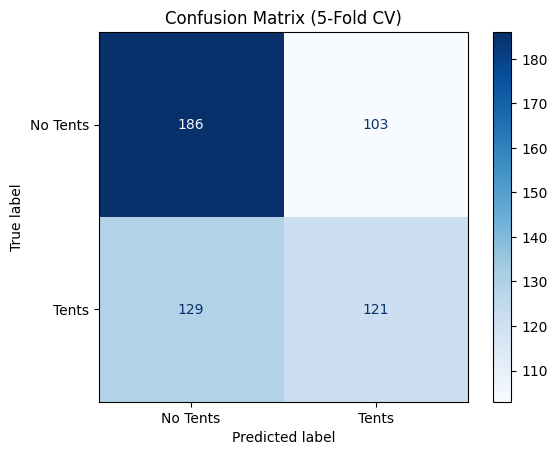

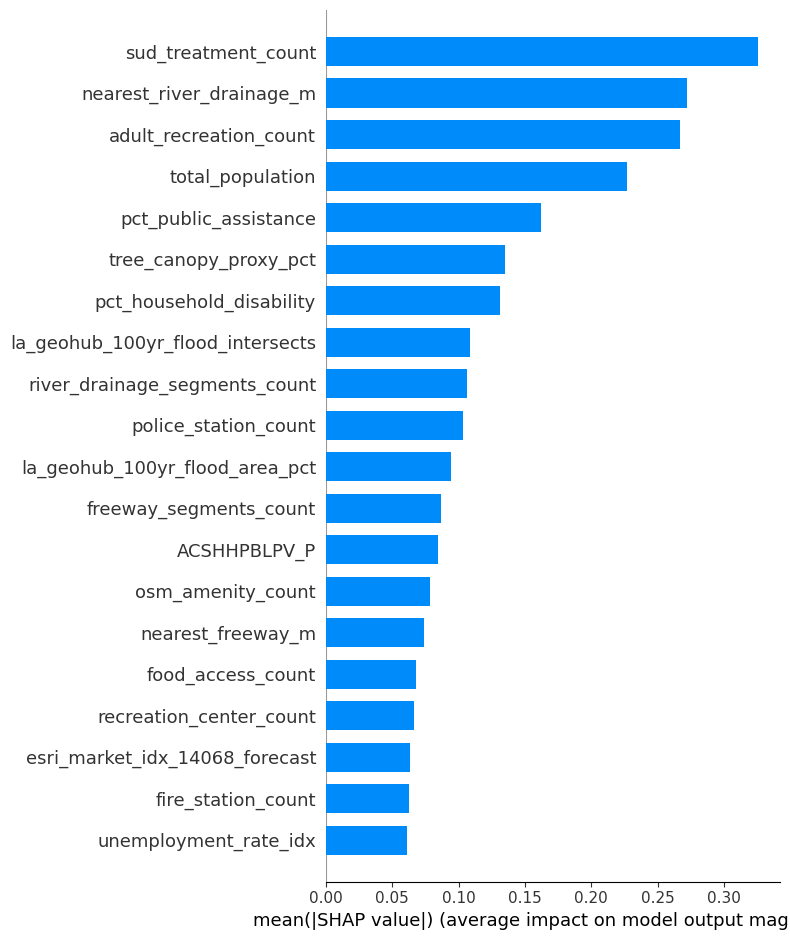

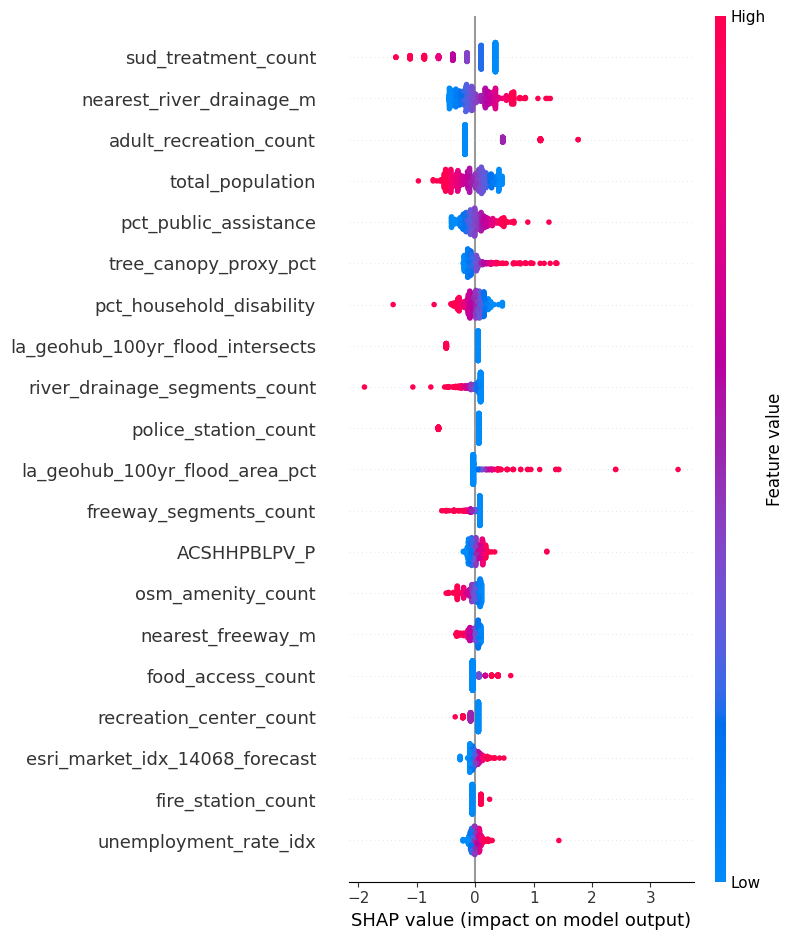

In [ ]:
# Standardize
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_final),
    columns=X_final.columns,
    index=X_final.index
)

# Model + CV
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# CV predictions
y_pred  = cross_val_predict(model, X_scaled, y_binary, cv=cv, method='predict')
y_proba = cross_val_predict(model, X_scaled, y_binary, cv=cv, method='predict_proba')[:, 1]

# Metrics
print(classification_report(y_binary, y_pred, target_names=['No Tents', 'Tents']))
print(f"AUC-ROC: {roc_auc_score(y_binary, y_proba):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_binary, y_pred,
    display_labels=['No Tents', 'Tents'],
    cmap='Blues'
)
plt.title("Confusion Matrix (5-Fold CV)")
plt.show()

# SHAP — fit on full data
model.fit(X_scaled, y_binary)
explainer   = shap.LinearExplainer(model, X_scaled, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_scaled)

shap.summary_plot(shap_values, X_scaled, plot_type="bar", max_display=20)
shap.summary_plot(shap_values, X_scaled, max_display=20)

In [ ]:
fpr, tpr, thresholds = roc_curve(y_binary, y_proba)
optimal_thresh = thresholds[np.argmax(tpr - fpr)]
y_pred_tuned   = (y_proba >= optimal_thresh).astype(int)

print(f"Optimal threshold: {optimal_thresh:.3f}")
print(classification_report(y_binary, y_pred_tuned, target_names=['No Tents', 'Tents']))

Optimal threshold: 0.490
              precision    recall  f1-score   support

    No Tents       0.61      0.63      0.62       289
       Tents       0.55      0.52      0.54       250

    accuracy                           0.58       539
   macro avg       0.58      0.58      0.58       539
weighted avg       0.58      0.58      0.58       539



In [ ]:
"""
RF Teacher → SNN Student Pipeline (v2)
========================================
Implements both:
  - SNN-1: 1-layer Superposable Neural Network (additive, one subnet per feature)
  - SNN-2: 2-layer SNN with pairwise interaction subnets on top of SNN-1

Distilled from a Random Forest teacher via 5-fold CV soft labels.

Architecture overview:
  SNN-1:  P(y=1) = σ( Σ_j  S_j(x_j) )
  SNN-2:  P(y=1) = σ( Σ_j  S_j(x_j)  +  Σ_{j<k} I_{jk}(x_j, x_k) )
"""

import argparse, json, os, warnings, itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

# ── Feature configuration ─────────────────────────────────────────────────────
FEATURES = [
    # Socioeconomic
    "total_crime_est",
    "total_population",
    "unemployment_rate_idx",
    "pct_household_disability",
    "pct_public_assistance",
    "pct_severe_rent_burden",
    "pct_no_schooling",
    "pct_no_health_insurance",
    "pct_veterans_2",
    "pct_hs_grad",
    "ACSHHPBLPV_P",
    "esri_market_idx_14068_forecast",
    # Facilities / Services
    "hospital_count",
    "fire_station_count",
    "library_count",
    "college_count",
    "public_school_count",
    "private_school_count",
    "recreation_center_count",
    "adult_recreation_count",
    "affordable_housing_count",
    "sud_treatment_count",
    "business_sites_count",
    "police_station_count",
    "food_access_count",
    "lausd_school_site_count",
    # Roads / Waterways
    "nearest_osm_major_road_m",
    "freeway_segments_count",
    "nearest_freeway_m",
    "river_drainage_segments_count",
    "nearest_river_drainage_m",
    "osm_amenity_count",
    # Flood / Hazard
    "fema_flood_hazard_area_pct",
    "fema_flood_hazard_intersects",
    "la_geohub_100yr_flood_area_pct",
    "la_geohub_100yr_flood_intersects",
    "la_geohub_500yr_flood_area_pct",
    "la_geohub_500yr_flood_intersects",
    "la_geohub_fire_hazard_area_pct",
    # Land Cover
    "tree_canopy_proxy_pct",
    "water_proxy_pct",
    "bare_ground_proxy_pct",
    "dominant_landcover_class",
]

FEATURE_LABELS = {
    "total_crime_est":                "Total Crime Est",
    "total_population":               "Total Population",
    "unemployment_rate_idx":          "Unemployment Rate Idx",
    "pct_household_disability":       "Pct HH Disability",
    "pct_public_assistance":          "Pct Public Assistance",
    "pct_severe_rent_burden":         "Pct Severe Rent Burden",
    "pct_no_schooling":               "Pct No Schooling",
    "pct_no_health_insurance":        "Pct No Health Insurance",
    "pct_veterans_2":                 "Pct Veterans",
    "pct_hs_grad":                    "Pct HS Grad",
    "ACSHHPBLPV_P":                   "Pct HH Below Poverty",
    "esri_market_idx_14068_forecast": "Market Idx 14068 Forecast",
    "hospital_count":                 "Hospitals",
    "fire_station_count":             "Fire Stations",
    "library_count":                  "Libraries",
    "college_count":                  "Colleges",
    "public_school_count":            "Public Schools",
    "private_school_count":           "Private Schools",
    "recreation_center_count":        "Recreation Centers",
    "adult_recreation_count":         "Adult Recreation",
    "affordable_housing_count":       "Affordable Housing",
    "sud_treatment_count":            "SUD Treatment Sites",
    "business_sites_count":           "Business Sites",
    "police_station_count":           "Police Stations",
    "food_access_count":              "Food Access Sites",
    "lausd_school_site_count":        "LAUSD Schools",
    "nearest_osm_major_road_m":       "Nearest Major Road (m)",
    "freeway_segments_count":         "Freeway Segments",
    "nearest_freeway_m":              "Nearest Freeway (m)",
    "river_drainage_segments_count":  "River Drainage Segments",
    "nearest_river_drainage_m":       "Nearest River Drainage (m)",
    "osm_amenity_count":              "OSM Amenities",
    "fema_flood_hazard_area_pct":     "FEMA Flood Hazard Pct",
    "fema_flood_hazard_intersects":   "FEMA Flood Intersects",
    "la_geohub_100yr_flood_area_pct": "100yr Flood Area Pct",
    "la_geohub_100yr_flood_intersects":"100yr Flood Intersects",
    "la_geohub_500yr_flood_area_pct": "500yr Flood Area Pct",
    "la_geohub_500yr_flood_intersects":"500yr Flood Intersects",
    "la_geohub_fire_hazard_area_pct": "Fire Hazard Area Pct",
    "tree_canopy_proxy_pct":          "Tree Canopy Pct",
    "water_proxy_pct":                "Water Pct",
    "bare_ground_proxy_pct":          "Bare Ground Pct",
    "dominant_landcover_class":       "Dominant Landcover Class",
}

TARGET_COL = "Join_Count"
ID_COL     = "OBJECTID"


# =============================================================================
# ARCHITECTURES
# =============================================================================

class SubNet1(nn.Module):
    def __init__(self, n_rbf: int = 10):
        super().__init__()
        self.centers    = nn.Parameter(torch.linspace(-2.5, 2.5, n_rbf))
        self.log_widths = nn.Parameter(torch.zeros(n_rbf))
        self.linear     = nn.Linear(n_rbf, 1, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x   = x.unsqueeze(1)
        c   = self.centers.unsqueeze(0)
        w   = torch.exp(self.log_widths).unsqueeze(0)
        rbf = torch.exp(-w * (x - c) ** 2)
        return self.linear(rbf).squeeze(1)

    def get_curve(self, x_range=(-3, 3), n_pts=200):
        xs = torch.linspace(*x_range, n_pts)
        with torch.no_grad():
            ys = self.forward(xs).numpy()
        return xs.numpy(), ys


class SubNet2(nn.Module):
    def __init__(self, n_rbf: int = 6):
        super().__init__()
        pts = torch.linspace(-2.5, 2.5, n_rbf)
        cj, ck = torch.meshgrid(pts, pts, indexing="ij")
        self.register_buffer("cj", cj.reshape(-1))
        self.register_buffer("ck", ck.reshape(-1))
        n_basis = n_rbf * n_rbf
        self.log_wj = nn.Parameter(torch.zeros(n_basis))
        self.log_wk = nn.Parameter(torch.zeros(n_basis))
        self.linear = nn.Linear(n_basis, 1, bias=True)

    def forward(self, xj: torch.Tensor, xk: torch.Tensor) -> torch.Tensor:
        wj  = torch.exp(self.log_wj)
        wk  = torch.exp(self.log_wk)
        phi = torch.exp(-wj * (xj.unsqueeze(1) - self.cj) ** 2) * \
              torch.exp(-wk * (xk.unsqueeze(1) - self.ck) ** 2)
        return self.linear(phi).squeeze(1)


# =============================================================================
# TRAINING: SNN-1
# =============================================================================

def train_snn1(X_np, soft_targets, hard_labels, n_rbf=10, n_rounds=4,
               epochs=500, lr=2e-3, verbose=True):
    n, n_feat = X_np.shape
    X_t = torch.tensor(X_np,         dtype=torch.float32)
    ts0 = torch.tensor(soft_targets, dtype=torch.float32)
    nets = [SubNet1(n_rbf) for _ in range(n_feat)]
    fo   = [torch.zeros(n) for _ in range(n_feat)]

    if verbose: print(f"  [SNN-1] Round 1/{n_rounds}: sequential distillation")
    residual = ts0.clone()
    for j, net in enumerate(nets):
        opt = torch.optim.Adam(net.parameters(), lr=lr)
        for _ in range(epochs):
            opt.zero_grad()
            nn.MSELoss()(net(X_t[:, j]), residual).backward()
            opt.step()
        with torch.no_grad():
            fo[j]    = net(X_t[:, j])
            residual = residual - fo[j]

    for rnd in range(1, n_rounds):
        lr_r = lr * (0.6 ** rnd)
        for j, net in enumerate(nets):
            others   = sum(fo[k].detach() for k in range(n_feat) if k != j)
            target_j = ts0 - others
            opt = torch.optim.Adam(net.parameters(), lr=lr_r)
            for _ in range(epochs):
                opt.zero_grad()
                nn.MSELoss()(net(X_t[:, j]), target_j).backward()
                opt.step()
            with torch.no_grad():
                fo[j] = net(X_t[:, j])
        if verbose:
            auc = roc_auc_score(
                hard_labels,
                torch.sigmoid(torch.stack(fo, 1).sum(1)).numpy()
            )
            print(f"  [SNN-1] Round {rnd+1}/{n_rounds}: AUC={auc:.4f}  lr={lr_r:.5f}")

    contribs = torch.stack(fo, 1).detach().numpy()
    probs    = torch.sigmoid(torch.tensor(contribs.sum(1), dtype=torch.float32)).numpy()
    return nets, contribs, probs


# =============================================================================
# TRAINING: SNN-2
# =============================================================================

def select_top_pairs(X_np, hard_labels, n_feat, top_k=20):
    print(f"  [SNN-2] Selecting top {top_k} pairs via RF interaction screen...")
    pairs    = list(itertools.combinations(range(n_feat), 2))
    products = np.column_stack([X_np[:, j] * X_np[:, k] for j, k in pairs])
    rf_screen = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)
    rf_screen.fit(products, hard_labels)
    ranked    = sorted(zip(pairs, rf_screen.feature_importances_), key=lambda x: -x[1])
    top_pairs = [p for p, _ in ranked[:top_k]]
    print(f"  [SNN-2] Top pair: {FEATURES[top_pairs[0][0]]} x {FEATURES[top_pairs[0][1]]}")
    return top_pairs


def train_snn2(X_np, soft_targets, hard_labels, snn1_contribs,
               top_pairs, n_rbf2=6, n_rounds=3, epochs=400, lr=1e-3, verbose=True):
    n    = X_np.shape[0]
    X_t  = torch.tensor(X_np,                dtype=torch.float32)
    ts0  = torch.tensor(soft_targets,         dtype=torch.float32)
    base = torch.tensor(snn1_contribs.sum(1), dtype=torch.float32)
    pair_nets = {jk: SubNet2(n_rbf2) for jk in top_pairs}
    pair_fo   = {jk: torch.zeros(n)  for jk in top_pairs}

    if verbose: print(f"  [SNN-2] Round 1/{n_rounds}: sequential interaction distillation")
    residual = ts0 - base
    for jk in top_pairs:
        j, k = jk
        net  = pair_nets[jk]
        opt  = torch.optim.Adam(net.parameters(), lr=lr)
        for _ in range(epochs):
            opt.zero_grad()
            nn.MSELoss()(net(X_t[:, j], X_t[:, k]), residual).backward()
            opt.step()
        with torch.no_grad():
            pair_fo[jk] = net(X_t[:, j], X_t[:, k])
            residual     = residual - pair_fo[jk]

    for rnd in range(1, n_rounds):
        lr_r = lr * (0.5 ** rnd)
        for jk in top_pairs:
            j, k   = jk
            others = sum(pair_fo[p].detach() for p in top_pairs if p != jk)
            target = ts0 - base - others
            opt    = torch.optim.Adam(pair_nets[jk].parameters(), lr=lr_r)
            for _ in range(epochs):
                opt.zero_grad()
                nn.MSELoss()(pair_nets[jk](X_t[:, j], X_t[:, k]), target).backward()
                opt.step()
            with torch.no_grad():
                pair_fo[jk] = pair_nets[jk](X_t[:, j], X_t[:, k])
        if verbose:
            total = base + sum(pair_fo[p].detach() for p in top_pairs)
            auc   = roc_auc_score(hard_labels, torch.sigmoid(total).numpy())
            print(f"  [SNN-2] Round {rnd+1}/{n_rounds}: AUC={auc:.4f}  lr={lr_r:.5f}")

    pair_contribs = np.column_stack([pair_fo[jk].detach().numpy() for jk in top_pairs])
    probs         = 1 / (1 + np.exp(-(base.numpy() + pair_contribs.sum(1))))
    return pair_nets, pair_contribs, probs


# =============================================================================
# HELPERS
# =============================================================================

def optimal_threshold(y, probs):
    fpr, tpr, thresholds = roc_curve(y, probs)
    return float(thresholds[np.argmax(tpr - fpr)])


def build_feature_summary(features, contribs, y, rf):
    delta    = contribs[y == 1].mean(0) - contribs[y == 0].mean(0)
    mean_abs = np.abs(contribs).mean(0)
    return pd.DataFrame({
        "feature":       features,
        "label":         [FEATURE_LABELS.get(f, f) for f in features],
        "rf_importance": rf.feature_importances_,
        "mean_abs_sj":   mean_abs,
        "delta_sj":      delta,
    }).sort_values("delta_sj", ascending=False).reset_index(drop=True)


def build_interaction_summary(top_pairs, pair_contribs, y, features):
    rows = []
    for idx, (j, k) in enumerate(top_pairs):
        col = pair_contribs[:, idx]
        rows.append({
            "feature_j":    features[j],
            "feature_k":    features[k],
            "label_j":      FEATURE_LABELS.get(features[j], features[j]),
            "label_k":      FEATURE_LABELS.get(features[k], features[k]),
            "mean_abs_Ijk": np.abs(col).mean(),
            "delta_Ijk":    col[y == 1].mean() - col[y == 0].mean(),
        })
    return pd.DataFrame(rows).sort_values("delta_Ijk", ascending=False).reset_index(drop=True)


def build_hex_output_snn1(ids, y, probs, contribs, features, thresh):
    contrib_df = pd.DataFrame(contribs, columns=[f"Sj_{f}" for f in features])
    return pd.concat([
        pd.Series(ids.values,                    name="hex_id"),
        pd.Series(y,                             name="tent_present"),
        pd.Series(probs,                         name="snn1_prob"),
        pd.Series((probs >= thresh).astype(int), name="snn1_pred"),
        contrib_df,
    ], axis=1)


def build_hex_output_snn2(ids, y, probs, snn1_contribs, pair_contribs,
                           features, top_pairs, thresh):
    snn1_df = pd.DataFrame(snn1_contribs, columns=[f"Sj_{f}" for f in features])
    pair_df = pd.DataFrame(
        {f"Ijk_{features[j]}_{features[k]}": pair_contribs[:, idx]
         for idx, (j, k) in enumerate(top_pairs)}
    )
    return pd.concat([
        pd.Series(ids.values,                    name="hex_id"),
        pd.Series(y,                             name="tent_present"),
        pd.Series(probs,                         name="snn2_prob"),
        pd.Series((probs >= thresh).astype(int), name="snn2_pred"),
        snn1_df, pair_df,
    ], axis=1)


def extract_curves_snn1(nets, features, X_raw):
    curves = {}
    for j, (f, net) in enumerate(zip(features, nets)):
        xs, ys = net.get_curve(x_range=(-3.0, 3.0), n_pts=200)
        x_raw  = np.linspace(float(X_raw[f].min()), float(X_raw[f].max()), 200)
        curves[f] = {
            "label": FEATURE_LABELS.get(f, f),
            "x_std": xs.tolist(),
            "x_raw": x_raw.tolist(),
            "y":     ys.tolist(),
        }
    return curves


def print_results(label, rf_auc, model_auc, model_ap, thresh, report):
    print("\n" + "=" * 60)
    print(f"RESULTS - {label}")
    print("=" * 60)
    print(f"  RF teacher AUC (CV):  {rf_auc:.4f}")
    print(f"  {label} AUC:          {model_auc:.4f}")
    print(f"  {label} AP:           {model_ap:.4f}")
    print(f"  Optimal threshold:    {thresh:.3f}")
    print()
    print(report)


def print_feature_table(summary):
    print("-- Feature contributions (dSj = tent - no-tent) ----------")
    print(f"{'#':<3} {'Feature':<32} {'dSj':>8}  direction")
    print("-" * 58)
    for i, row in summary.iterrows():
        bar = ("^" if row["delta_sj"] > 0 else "v") * min(int(abs(row["delta_sj"]) / 0.005), 20)
        print(f"{i+1:<3} {row['label']:<32} {row['delta_sj']:>+8.4f}  {bar}")


def print_interaction_table(inter_summary, top_n=15):
    print(f"\n-- Top interaction contributions (dI_jk) ----------------")
    print(f"{'#':<3} {'Pair':<48} {'dIjk':>8}")
    print("-" * 62)
    for i, row in inter_summary.head(top_n).iterrows():
        pair = f"{row['label_j']} x {row['label_k']}"
        print(f"{i+1:<3} {pair:<48} {row['delta_Ijk']:>+8.4f}")


# =============================================================================
# MAIN
# =============================================================================

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data",      default="/content/three_fourth_tent_overview_enriched.csv")
    parser.add_argument("--out",       default="outputs")
    parser.add_argument("--rbf",       type=int,   default=10)
    parser.add_argument("--rbf2",      type=int,   default=6)
    parser.add_argument("--rounds",    type=int,   default=4)
    parser.add_argument("--rounds2",   type=int,   default=3)
    parser.add_argument("--epochs",    type=int,   default=500)
    parser.add_argument("--epochs2",   type=int,   default=400)
    parser.add_argument("--lr",        type=float, default=2e-3)
    parser.add_argument("--lr2",       type=float, default=1e-3)
    parser.add_argument("--top_pairs", type=int,   default=20)
    args, _ = parser.parse_known_args()

    os.makedirs(args.out, exist_ok=True)

    # ── Load ──────────────────────────────────────────────────────────────────
    try:
        X   = X_final[FEATURES].fillna(0).reset_index(drop=True)
        y   = y_binary.values if hasattr(y_binary, "values") else np.array(y_binary)
        ids = pd.Series(range(len(X)))
        print(f"\nUsing in-memory X_final / y_binary ({len(X)} hexes)")
    except NameError:
        print(f"\nLoading: {args.data}")
        df  = pd.read_csv(args.data)
        X   = df[FEATURES].fillna(0)
        y   = (df[TARGET_COL] > 0).astype(int).values
        ids = df[ID_COL] if ID_COL in df.columns else pd.Series(range(len(df)))

    print(f"  {len(X)} hexes | {len(FEATURES)} features | "
          f"{y.sum()} tent-present ({y.mean()*100:.1f}%)")

    # ── Scale ─────────────────────────────────────────────────────────────────
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── RF Teacher ────────────────────────────────────────────────────────────
    print("\nStep 1: RF teacher (5-fold CV soft labels)...")
    rf = RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        max_depth=8, random_state=42, n_jobs=-1,
    )
    cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    soft_labels = cross_val_predict(rf, X_scaled, y, cv=cv, method="predict_proba")[:, 1]
    rf.fit(X_scaled, y)
    rf_auc = roc_auc_score(y, soft_labels)
    print(f"  RF AUC (CV): {rf_auc:.4f}")

    # =========================================================================
    # SNN-1
    # =========================================================================
    print(f"\nStep 2: SNN-1 distillation "
          f"(rbf={args.rbf}, rounds={args.rounds}, epochs={args.epochs})...")
    nets1, contribs1, probs1 = train_snn1(
        X_scaled, soft_labels, y,
        n_rbf=args.rbf, n_rounds=args.rounds,
        epochs=args.epochs, lr=args.lr, verbose=True,
    )

    thresh1  = optimal_threshold(y, probs1)
    auc1     = roc_auc_score(y, probs1)
    ap1      = average_precision_score(y, probs1)
    preds1   = (probs1 >= thresh1).astype(int)
    report1  = classification_report(y, preds1, target_names=["no tent", "tent"])
    summary1 = build_feature_summary(FEATURES, contribs1, y, rf)

    print_results("SNN-1", rf_auc, auc1, ap1, thresh1, report1)
    print_feature_table(summary1)

    hex1    = build_hex_output_snn1(ids, y, probs1, contribs1, FEATURES, thresh1)
    curves1 = extract_curves_snn1(nets1, FEATURES, X)

    summary1.to_csv(f"{args.out}/snn1_feature_summary.csv",   index=False)
    hex1.to_csv(    f"{args.out}/snn1_hex_contributions.csv", index=False)
    with open(f"{args.out}/snn1_curves.json", "w") as fh:
        json.dump(curves1, fh)
    with open(f"{args.out}/snn1_metrics.txt", "w") as fh:
        fh.write(f"RF teacher AUC (CV): {rf_auc:.4f}\n")
        fh.write(f"SNN-1 AUC:           {auc1:.4f}\n")
        fh.write(f"SNN-1 AP:            {ap1:.4f}\n")
        fh.write(f"Optimal threshold:   {thresh1:.3f}\n\n")
        fh.write(report1)
    torch.save({
        "nets":         [n.state_dict() for n in nets1],
        "scaler_mean":  scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
        "features":     FEATURES,
        "threshold":    thresh1,
        "n_rbf":        args.rbf,
    }, f"{args.out}/snn_model1.pt")

    # =========================================================================
    # SNN-2
    # =========================================================================
    print(f"\nStep 3: SNN-2 - selecting top {args.top_pairs} pairwise interactions...")
    top_pairs = select_top_pairs(X_scaled, y, len(FEATURES), top_k=args.top_pairs)

    print(f"\nStep 4: SNN-2 interaction distillation "
          f"(rbf2={args.rbf2}, rounds={args.rounds2}, epochs={args.epochs2})...")
    pair_nets, pair_contribs, probs2 = train_snn2(
        X_scaled, soft_labels, y, contribs1,
        top_pairs, n_rbf2=args.rbf2, n_rounds=args.rounds2,
        epochs=args.epochs2, lr=args.lr2, verbose=True,
    )

    thresh2   = optimal_threshold(y, probs2)
    auc2      = roc_auc_score(y, probs2)
    ap2       = average_precision_score(y, probs2)
    preds2    = (probs2 >= thresh2).astype(int)
    report2   = classification_report(y, preds2, target_names=["no tent", "tent"])
    summary2  = build_feature_summary(FEATURES, contribs1, y, rf)
    inter_sum = build_interaction_summary(top_pairs, pair_contribs, y, FEATURES)

    print_results("SNN-2", rf_auc, auc2, ap2, thresh2, report2)
    print_feature_table(summary2)
    print_interaction_table(inter_sum)
    print(f"\n  AUC lift SNN-1 -> SNN-2: {auc1:.4f} -> {auc2:.4f} "
          f"({(auc2-auc1)*100:+.2f} pp)")

    hex2 = build_hex_output_snn2(
        ids, y, probs2, contribs1, pair_contribs, FEATURES, top_pairs, thresh2
    )
    summary2.to_csv(  f"{args.out}/snn2_feature_summary.csv",    index=False)
    inter_sum.to_csv( f"{args.out}/snn2_interaction_summary.csv", index=False)
    hex2.to_csv(      f"{args.out}/snn2_hex_contributions.csv",   index=False)
    with open(f"{args.out}/snn2_metrics.txt", "w") as fh:
        fh.write(f"RF teacher AUC (CV): {rf_auc:.4f}\n")
        fh.write(f"SNN-1 AUC:           {auc1:.4f}\n")
        fh.write(f"SNN-2 AUC:           {auc2:.4f}\n")
        fh.write(f"SNN-2 AP:            {ap2:.4f}\n")
        fh.write(f"Optimal threshold:   {thresh2:.3f}\n\n")
        fh.write(report2)
    torch.save({
        "snn1_nets":    [n.state_dict() for n in nets1],
        "pair_nets":    {str(k): v.state_dict() for k, v in pair_nets.items()},
        "top_pairs":    top_pairs,
        "scaler_mean":  scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
        "features":     FEATURES,
        "threshold":    thresh2,
        "n_rbf":        args.rbf,
        "n_rbf2":       args.rbf2,
    }, f"{args.out}/snn_model2.pt")

    print("\n" + "=" * 60)
    print("ALL OUTPUTS")
    print("=" * 60)
    for fname in [
        "snn1_feature_summary.csv", "snn1_hex_contributions.csv",
        "snn1_curves.json", "snn1_metrics.txt", "snn_model1.pt",
        "snn2_feature_summary.csv", "snn2_interaction_summary.csv",
        "snn2_hex_contributions.csv", "snn2_metrics.txt", "snn_model2.pt",
    ]:
        print(f"  -> {args.out}/{fname}")


if __name__ == "__main__":
    main()


Using in-memory X_final / y_binary (539 hexes)
  539 hexes | 43 features | 250 tent-present (46.4%)

Step 1: RF teacher (5-fold CV soft labels)...
  RF AUC (CV): 0.6143

Step 2: SNN-1 distillation (rbf=10, rounds=4, epochs=500)...
  [SNN-1] Round 1/4: sequential distillation
  [SNN-1] Round 2/4: AUC=0.7127  lr=0.00120
  [SNN-1] Round 3/4: AUC=0.7182  lr=0.00072
  [SNN-1] Round 4/4: AUC=0.7165  lr=0.00043

RESULTS - SNN-1
  RF teacher AUC (CV):  0.6143
  SNN-1 AUC:          0.7165
  SNN-1 AP:           0.6773
  Optimal threshold:    0.619

              precision    recall  f1-score   support

     no tent       0.69      0.65      0.67       289
        tent       0.62      0.66      0.64       250

    accuracy                           0.66       539
   macro avg       0.66      0.66      0.66       539
weighted avg       0.66      0.66      0.66       539

-- Feature contributions (dSj = tent - no-tent) ----------
#   Feature                               dSj  direction
-----------

In [ ]:
print(X_final.columns.tolist())


['total_crime_est', 'total_population', 'unemployment_rate_idx', 'pct_household_disability', 'pct_public_assistance', 'pct_severe_rent_burden', 'pct_no_schooling', 'pct_no_health_insurance', 'pct_veterans_2', 'pct_hs_grad', 'ACSHHPBLPV_P', 'esri_market_idx_14068_forecast', 'hospital_count', 'fire_station_count', 'library_count', 'college_count', 'public_school_count', 'private_school_count', 'recreation_center_count', 'adult_recreation_count', 'affordable_housing_count', 'sud_treatment_count', 'business_sites_count', 'police_station_count', 'food_access_count', 'lausd_school_site_count', 'nearest_osm_major_road_m', 'freeway_segments_count', 'nearest_freeway_m', 'river_drainage_segments_count', 'nearest_river_drainage_m', 'osm_amenity_count', 'fema_flood_hazard_area_pct', 'fema_flood_hazard_intersects', 'la_geohub_100yr_flood_area_pct', 'la_geohub_100yr_flood_intersects', 'la_geohub_500yr_flood_area_pct', 'la_geohub_500yr_flood_intersects', 'la_geohub_fire_hazard_area_pct', 'tree_canopy

In [ ]:
print(df_25['GRID_ID'].nunique())

In [ ]:
print(X_final.columns.tolist())

['2024 Total Crime Index', '2024 Total Population', '2024 Unemployment Rate: Index', '2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent', '2023 HHs w/Public Assist Income (ACS 5-Yr): Percent', '2023 Pop w/Income Below Poverty Level (ACS 5-Yr): Percent', '2023 HHs/Gross Rent 50+% of Income (ACS 5-Yr): Percent', '2023 Pop 25+: No Schooling (ACS 5-Yr): Percent', '2023 Pop 35-64: No Health Insurance (ACS 5-Yr): Percent', '2023 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent', '2023 Pop 25+: HS Diploma (ACS 5-Yr): Percent', '2030 Value of Credit Card Debt: Index', 'total_crime_est', 'total_population', 'burglary_crime_est', 'unemployment_rate_idx', 'pct_household_disability', 'pct_public_assistance', 'pct_below_poverty', 'pct_severe_rent_burden', 'pct_no_schooling', 'pct_no_health_insurance', 'pct_veterans_2', 'pct_hs_grad', 'esri_market_idx_14068_forecast', 'hospital_count', 'fire_station_count', 'library_count', 'college_count', 'public_school_count', 'private_school_count', 'recreatio

In [ ]:
print("Columns in df_25:")
print(df_25.columns.tolist())

Columns in df_25:
['OBJECTID', 'Join_Count', 'TARGET_FID_x', 'GRID_ID_x', 'Id', 'Country code', 'ENRICH_FID_x', 'Aggregation method', 'Population to polygon size rating for the country', 'Apportionment confidence for the country', 'Has data', '2024 Total Crime Index', '2024 Total Population', '2024 Burglary Index', '2024 Unemployment Rate: Index', '2024 Hispanic Population: Percent', '2022 Civilian Pop 18+: Veteran (ACS 5-Yr): Percent', '2024 Median Household Income: Index', 'Id.1', 'Country code.1', 'ENRICH_FID.1', 'Aggregation method.1', 'Population to polygon size rating for the country.1', 'Apportionment confidence for the country.1', 'Has data.1', '2023 HHs w/1+ Persons w/Disability (ACS 5-Yr): Percent', '2023 HHs w/Public Assist Income (ACS 5-Yr): Percent', '2023 Pop w/Income Below Poverty Level (ACS 5-Yr): Percent', '2023 HHs/Gross Rent 50+% of Income (ACS 5-Yr): Percent', '2023 Pop 25+: No Schooling (ACS 5-Yr): Percent', '2023 Pop 35-64: No Health Insurance (ACS 5-Yr): Percent'

In [ ]:
df_25['GRID_ID'].nunique()

KeyError: 'GRID_ID'

In [ ]:
df_25

,OBJECTID,Join_Count,TARGET_FID_x,GRID_ID_x,Id,Country code,ENRICH_FID_x,Aggregation method,Population to polygon size rating for the country,Apportionment confidence for the country,...,la_geohub_fire_hazard_intersects,heat_exposure_area_pct,heat_exposure_intersects,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,dominant_landcover_class,heat_exposure_proxy_score
0,1,0,1,AP-81,0,US,1,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,1.80,46.13,22.68,1.29,29.90,3,45.34
1,2,0,2,AQ-81,1,US,2,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,1.25,33.86,35.74,1.88,28.53,5,54.64
2,3,0,3,AR-81,2,US,3,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,1.25,33.86,35.74,1.88,28.53,5,54.64
3,4,0,4,AP-80,3,US,4,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,0.23,7.71,14.72,55.37,22.20,6,40.24
4,5,0,5,AQ-80,4,US,5,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,1.95,28.77,45.29,1.07,24.87,5,61.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,1444,0,1444,X-2,43,US,1444,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,1.24,18.37,60.95,1.94,18.73,5,72.29
1444,1445,0,1445,Y-2,44,US,1445,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,5.00,34.48,35.52,1.72,28.28,5,53.36
1445,1446,0,1446,U-1,45,US,1446,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,9.57,35.82,42.20,2.30,19.68,5,56.67
1446,1447,0,1447,W-1,46,US,1447,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,0.52,24.14,46.72,1.03,28.10,5,62.55


In [ ]:
import pandas as pd
df_tent = pd.read_csv('/content/outputLayer_0 7.csv')

In [ ]:
df_25 = pd.merge(df_tent,df_25,on = 'OBJECTID',how='inner' )

MergeError: Passing 'suffixes' which cause duplicate columns {'Join_Count_y'} is not allowed.

In [ ]:
df_25.shape

(1448, 134)

In [ ]:
df_25

,OBJECTID,Join_Count,TARGET_FID_x,GRID_ID_x,Id,Country code,ENRICH_FID_x,Aggregation method,Population to polygon size rating for the country,Apportionment confidence for the country,...,la_geohub_fire_hazard_intersects,heat_exposure_area_pct,heat_exposure_intersects,tree_canopy_proxy_pct,vegetation_proxy_pct,impervious_proxy_pct,water_proxy_pct,bare_ground_proxy_pct,dominant_landcover_class,heat_exposure_proxy_score
0,1,0,1,AP-81,0,US,1,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,1.80,46.13,22.68,1.29,29.90,3,45.34
1,2,0,2,AQ-81,1,US,2,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,1.25,33.86,35.74,1.88,28.53,5,54.64
2,3,0,3,AR-81,2,US,3,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,1.25,33.86,35.74,1.88,28.53,5,54.64
3,4,0,4,AP-80,3,US,4,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,0.23,7.71,14.72,55.37,22.20,6,40.24
4,5,0,5,AQ-80,4,US,5,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,1.95,28.77,45.29,1.07,24.87,5,61.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,1444,0,1444,X-2,43,US,1444,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,1.24,18.37,60.95,1.94,18.73,5,72.29
1444,1445,0,1445,Y-2,44,US,1445,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,5.00,34.48,35.52,1.72,28.28,5,53.36
1445,1446,0,1446,U-1,45,US,1446,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,9.57,35.82,42.20,2.30,19.68,5,56.67
1446,1447,0,1447,W-1,46,US,1447,BlockApportionment:US.BlockGroups;PointsLayer:...,2.19,2.58,...,1,0.00,0,0.52,24.14,46.72,1.03,28.10,5,62.55


In [ ]:
df_25['Join_Count_x'].value_counts()

KeyError: 'Join_Count_x'

In [ ]:
df_25.shape

(1448, 134)

In [ ]:
df_25 =  df_25.rename(columns = {'Join_Count_x':'Join_Count'})

In [ ]:
## Taking required features
# Identify all columns to be dropped for feature processing, including ID/coordinate columns
columns_to_drop_for_features = [
    'OBJECTID','TARGET_FID_x','JOIN_FID','ID','sourceCountry','ENRICH_FID_x','aggregationMethod','populationToPolygonSizeRating','apportionmentConfidence','HasData',
    'ID_1','sourceCountry_1','ENRICH_FID_1','populationToPolygonSizeRating_1','aggregationMethod_1','populationToPolygonSizeRating_1','HasData_1',
    'source_run','address','heading','filename','tent_prediction_count','max_conf','classes_seen','tent_ref_max_conf','tent_ref_mean_conf',
    'Id','Country code','Aggregation method','Population to polygon size rating for the country','Apportionment confidence for the country','Has data',
    'Join_Count_y','TARGET_FID_y','ENRICH_FID_y'
]

# Coordinate/identifier columns that need to be separated for later rejoining
id_coord_to_separate = ['GRID_ID_x', 'GRID_ID_y', 'latitude', 'longitude']

# Capture the ID/coordinate columns from the original df_25 before any other drops
present_id_coord_cols = [col for col in id_coord_to_separate if col in df_25.columns]
df_id_coords = df_25[present_id_coord_cols].copy()

# Create df_25_feature by dropping all specified columns and also the ID/coordinate columns
# We will also ensure it is purely numeric in the next step.
df_25_feature = df_25.drop(columns=columns_to_drop_for_features + id_coord_to_separate, axis=1, errors='ignore')

# Ensure df_25_feature is purely numeric for feature processing steps
df_25_feature = df_25_feature.select_dtypes(include=np.number)
